In [162]:
import os
import pandas as pd
import glob
lc = pd.read_csv("data/objetos/OGLE-2024-BLG-0034/lightcurve.csv")
import numpy as np

import matplotlib.pyplot as plt
# Process lc data for I and V bands
lc['I_mag'] = lc['I'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['V_mag'] = lc['V'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['mjd_dt'] = pd.to_datetime(lc['mjd'], unit='D', origin=pd.Timestamp('1858-11-17'))
from astropy.io import fits
temperature = []
airmasses = []
exptimes = []
for file in lc.fname:
    try:
        # sólo se extrae la llave CAMTEM del primer HDU
        camtem = fits.getval(file, 'CAMTEM', ext=0)
        airmass = fits.getval(file, 'AIRMASS', ext=0)
        exptime = fits.getval(file, 'EXPTIME', ext=0)
        temperature.append(camtem)
        airmasses.append(airmass)
        exptimes.append(exptime)
    except Exception as e:
        print(f"Could not read CAMTEM for {file}: {e}")  
lc['camtem'] = temperature
lc['camtem'] = pd.to_numeric(lc['camtem'], errors='coerce')
lc['airmass'] = airmasses
lc['airmass'] = pd.to_numeric(lc['airmass'], errors='coerce')
lc['exptime'] = exptimes
lc['exptime'] = pd.to_numeric(lc['exptime'], errors='coerce')
directory = "data/objetos/OGLE-2024-BLG-0034/"
photometry_files = glob.glob(os.path.join(directory, "*photometry_*.csv"))
if photometry_files:
    dates = [pd.to_datetime(f.split('_')[-1].replace('.csv', '')) for f in photometry_files]
    most_recent_file = photometry_files[dates.index(max(dates))]
    phot = pd.read_csv(most_recent_file)
    phot['Magnitude_clean'] = phot['Magnitude'].apply(lambda x: float(x) if not str(x).startswith('>') else np.nan)
    phot['Timestamp_dt'] = pd.to_datetime(phot['Timestamp'])
    print(f"Most recent photometry file: {most_recent_file}")
else:
    print("No photometry files found.") 

Most recent photometry file: data/objetos/OGLE-2024-BLG-0034/OGLE-2024-BLG-0034_photometry_20260219.csv


In [3]:
lc.columns, phot.columns


(Index(['I', 'INSTRUME', 'I_err', 'I_inst', 'I_inst_err', 'SNR', 'TELESCOP',
        'V', 'V_err', 'V_inst', 'V_inst_err', 'aperature_correction',
        'aperature_correction_err', 'beta', 'fname', 'fwhm', 'fwhm_err',
        'instrument', 'lmag_inject', 'lmag_prob', 'method', 'mjd',
        'pixel_offset', 'subtraction', 'target_fwhm', 'telescope', 'time',
        'time_taken', 'xpix', 'ypix', 'zp_I', 'zp_I_err', 'zp_V', 'zp_V_err',
        'I_mag', 'V_mag', 'mjd_dt', 'camtem', 'airmass', 'exptime'],
       dtype='object'),
 Index(['Timestamp', 'Telescope', 'Filter', 'Magnitude', 'Error', 'Source',
        'Magnitude_clean', 'Timestamp_dt'],
       dtype='object'))

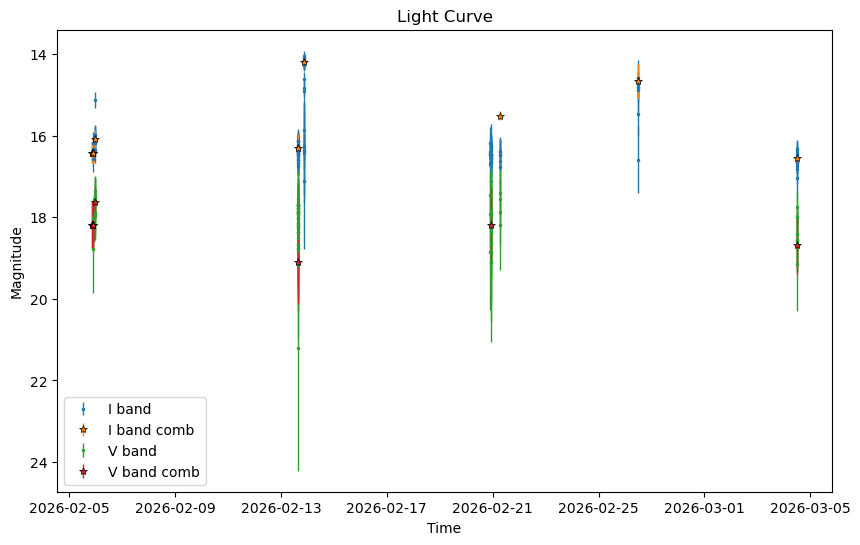

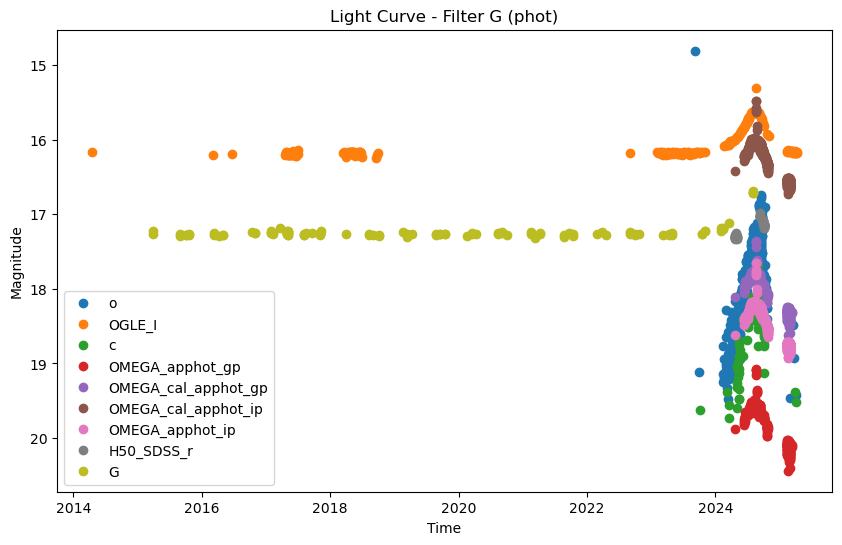

In [3]:
import numpy as np

import matplotlib.pyplot as plt

# Process lc data for I and V bands
lc['I_mag'] = lc['I'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['V_mag'] = lc['V'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['time_dt'] = pd.to_datetime(lc['time'])

fig, ax = plt.subplots(figsize=(10, 6))
# Plot I band
mask_i = lc['I_mag'].notna()
comb_mask_i = mask_i & lc['fname'].str.contains('comb')
non_comb_mask_i = mask_i & ~lc['fname'].str.contains('comb')
ax.errorbar(lc.loc[non_comb_mask_i, 'time_dt'], lc.loc[non_comb_mask_i, 'I_mag'], 
            yerr=lc.loc[non_comb_mask_i, 'I_err'], fmt='o', ms=1.5, elinewidth=1, label='I band')
ax.errorbar(lc.loc[comb_mask_i, 'time_dt'], lc.loc[comb_mask_i, 'I_mag'], 
            yerr=lc.loc[comb_mask_i, 'I_err'], fmt='*', elinewidth=1, markeredgecolor='black', markeredgewidth=0.5, label='I band comb')

# Plot V band
mask_v = lc['V_mag'].notna()
comb_mask_v = mask_v & lc['fname'].str.contains('comb')
non_comb_mask_v = mask_v & ~lc['fname'].str.contains('comb')
ax.errorbar(lc.loc[non_comb_mask_v, 'time_dt'], lc.loc[non_comb_mask_v, 'V_mag'], 
            yerr=lc.loc[non_comb_mask_v, 'V_err'], fmt='o',  ms=1.5, elinewidth=1, label='V band')
ax.errorbar(lc.loc[comb_mask_v, 'time_dt'], lc.loc[comb_mask_v, 'V_mag'], 
            yerr=lc.loc[comb_mask_v, 'V_err'], fmt='*', elinewidth=1, markeredgecolor='black', markeredgewidth=0.5, label='V band comb')

ax.set_title('Light Curve')
ax.set_xlabel('Time')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()
plt.legend()

# Process phot data
phot['Magnitude_clean'] = phot['Magnitude'].apply(lambda x: float(x) if not str(x).startswith('>') else np.nan)
phot['Timestamp_dt'] = pd.to_datetime(phot['Timestamp'])

# Get unique filters in phot
filters = phot['Filter'].unique()
fig, ax = plt.subplots(figsize=(10, 6))
# Plot for each filter in phot
for f in filters:

    mask = (phot['Filter'] == f) & phot['Magnitude_clean'].notna()
    ax.plot(phot.loc[mask, 'Timestamp_dt'], phot.loc[mask, 'Magnitude_clean'], 'o', label=f)
    ax.set_title(f'Light Curve - Filter {f} (phot)')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()
ax.legend()

First mag OGLE_I: 16.169 at 2025-04-08 09:55:01
Last mag OGLE_I: 16.173 at 2014-04-18 08:38:23
{
    "Alive": "False",
    "Observing mode": "No",
    "TAP priority": "8.14726\u22132.00946",
    "Interferometry candidate": "False",
    "t0 [HJD]": "2460535.45236\u22130.28225",
    "u0": "0.58836\u22130.10426",
    "tE [days]": "100.85102\u221313.49129",
    "Mag now": "16.152960273847597",
    "Latest data": "2025-04-13 00:59:11",
    "Last fit": "2460777.777367713",
    "mop_link": "https://mop.lco.global/targets/42858/",
    "RA": "17:44:10.400",
    "Dec": "-39:06:47.60",
    "l": "351.1432",
    "b": "-5.0419"
}


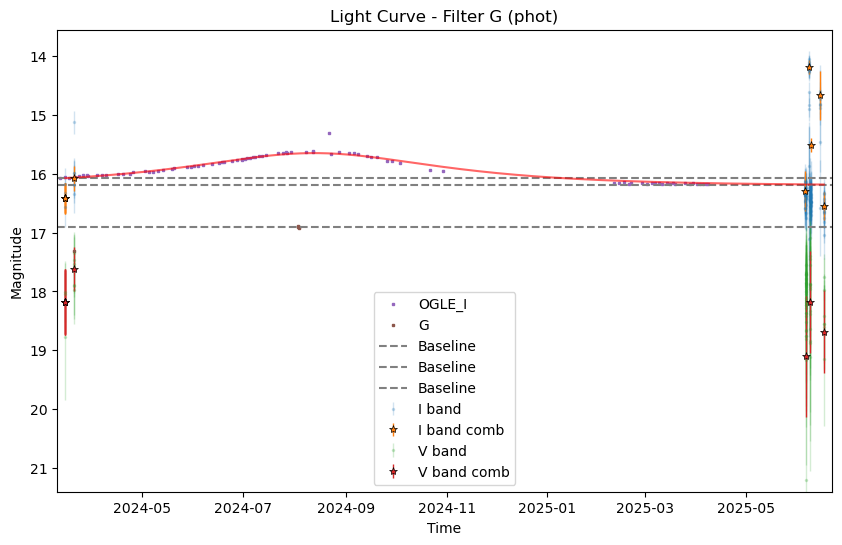

In [53]:
import numpy as np
import matplotlib.pyplot as plt
# Process lc data for I and V bands

lc['I_mag'] = lc['I'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['V_mag'] = lc['V'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['mjd_dt'] = pd.to_datetime(lc['mjd'], unit='D', origin=pd.Timestamp('1858-11-17'))

fig, ax = plt.subplots(figsize=(10, 6))
# Plot I band
mask_i = lc['I_mag'].notna()
comb_mask_i = mask_i & lc['fname'].str.contains('comb')
non_comb_mask_i = mask_i & ~lc['fname'].str.contains('comb')
ax.errorbar(lc.loc[non_comb_mask_i, 'mjd_dt'], lc.loc[non_comb_mask_i, 'I_mag'], 
            yerr=lc.loc[non_comb_mask_i, 'I_err'], fmt='o', alpha=0.2, ms=1.5, elinewidth=1, label='I band')
ax.errorbar(lc.loc[comb_mask_i, 'mjd_dt'], lc.loc[comb_mask_i, 'I_mag'], 
            yerr=lc.loc[comb_mask_i, 'I_err'], fmt='*', elinewidth=1, markeredgecolor='black', markeredgewidth=0.5, label='I band comb')

# Plot V band
mask_v = lc['V_mag'].notna()
comb_mask_v = mask_v & lc['fname'].str.contains('comb')
non_comb_mask_v = mask_v & ~lc['fname'].str.contains('comb')
ax.errorbar(lc.loc[non_comb_mask_v, 'mjd_dt'], lc.loc[non_comb_mask_v, 'V_mag'], 
            yerr=lc.loc[non_comb_mask_v, 'V_err'], fmt='o',  alpha=0.2, ms=1.5, elinewidth=1, label='V band')
ax.errorbar(lc.loc[comb_mask_v, 'mjd_dt'], lc.loc[comb_mask_v, 'V_mag'], 
            yerr=lc.loc[comb_mask_v, 'V_err'], fmt='*', elinewidth=1, markeredgecolor='black', markeredgewidth=0.5, label='V band comb')

ax.set_title('Light Curve')
ax.set_xlabel('Time')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()
plt.legend()

# Process phot data
phot['Magnitude_clean'] = phot['Magnitude'].apply(lambda x: float(x) if not str(x).startswith('>') else np.nan)
phot['Timestamp_dt'] = pd.to_datetime(phot['Timestamp'])

# Get unique filters in phot
filters = phot['Filter'].unique()
# Plot for each filter in phot
for f in filters:
    if f == "OGLE_I":
        mask = (phot['Filter'] == f) & phot['Magnitude_clean'].notna()
        ax.plot(phot.loc[mask, 'Timestamp_dt'], phot.loc[mask, 'Magnitude_clean'], 's',ms=2,  label=f)
        print(f"First mag OGLE_I: {phot.loc[mask, 'Magnitude_clean'].iloc[0]} at {phot.loc[mask, 'Timestamp_dt'].iloc[0]}")
        print(f"Last mag OGLE_I: {phot.loc[mask, 'Magnitude_clean'].iloc[-1]} at {phot.loc[mask, 'Timestamp_dt'].iloc[-1]}")
        first_mag_ogle_i = phot.loc[mask, 'Magnitude_clean'].iloc[0]
        first_time_ogle_i = phot.loc[mask, 'Timestamp_dt'].iloc[0]
        last_mag_ogle_i = phot.loc[mask, 'Magnitude_clean'].iloc[-1]
        last_time_ogle_i = phot.loc[mask, 'Timestamp_dt'].iloc[-1]
    elif f == "G":
        mask = (phot['Filter'] == f) & phot['Magnitude_clean'].notna()
        ax.plot(phot.loc[mask, 'Timestamp_dt'], phot.loc[mask, 'Magnitude_clean']+0.2, 's',ms=2,  label=f)
    ax.set_title(f'Light Curve - Filter {f} (phot)')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()
ax.axhline(16.19, color='gray', linestyle='--', label='Baseline')
ax.axhline(16.07, color='gray', linestyle='--', label='Baseline')
ax.axhline(16.9, color='gray', linestyle='--', label='Baseline')
ax.legend(loc='lower center')
ax.set_xlim(lc['mjd_dt'].min()-pd.Timedelta(days=5), lc['mjd_dt'].max()+pd.Timedelta(days=5))
ax.set_ylim(lc[['I_mag', 'V_mag']].max().max() + 0.2, lc[['I_mag', 'V_mag']].min().min() - 0.5)
params_path = "microlensing_data/OGLE-2024-BLG-0034_20260211.json"
# Leer json:
import json
import re
with open(params_path, 'r') as f:
    params = json.load(f)
print(json.dumps(params, indent=4))

# Plotear modelo con parámetros del json
def microlensing_model(t, t0, u0, tE, mag_base):
    u = np.sqrt(u0**2 + ((t - t0) / tE)**2)
    A = (u**2 + 2) / (u * np.sqrt(u**2 + 4))
    return mag_base - 2.5 * np.log10(A)
t = np.linspace(lc['mjd_dt'].min().value, lc['mjd_dt'].max().value, 1000)
t = pd.to_datetime(t)
# create numeric time grid in MJD and corresponding datetimes for plotting
t_mjd = np.linspace(lc['mjd'].min(), lc['mjd'].max(), 1000)
t = pd.to_datetime(t_mjd, unit='D', origin=pd.Timestamp('1858-11-17'))

def _parse_num(x):
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if x is None:
        return np.nan
    m = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', str(x))
    return float(m.group()) if m else np.nan

t0 = _parse_num(params.get('t0') or params.get('t0 [HJD]'))-2400000.5
u0 = _parse_num(params.get('u0'))*1.2
tE = _parse_num(params.get('tE') or params.get('tE [days]'))*1.1
mag_base = _parse_num(params.get('mag_base') or params.get('Mag now') or params.get('Mag_now'))+0.05

model_mag = microlensing_model(t_mjd, t0, u0, tE, mag_base)

ax.plot(t, model_mag, label='Microlensing Model', alpha=0.6, color='red')


In [54]:


first_mag_ogle_i, first_time_ogle_i, last_mag_ogle_i, last_time_ogle_i

(np.float64(16.169),
 Timestamp('2025-04-08 09:55:01'),
 np.float64(16.173),
 Timestamp('2014-04-18 08:38:23'))

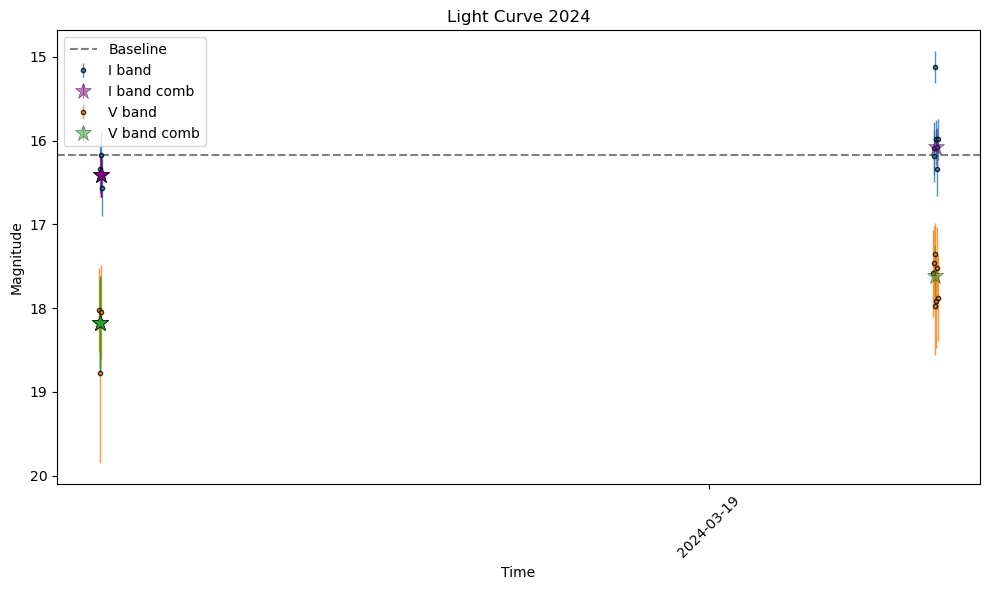

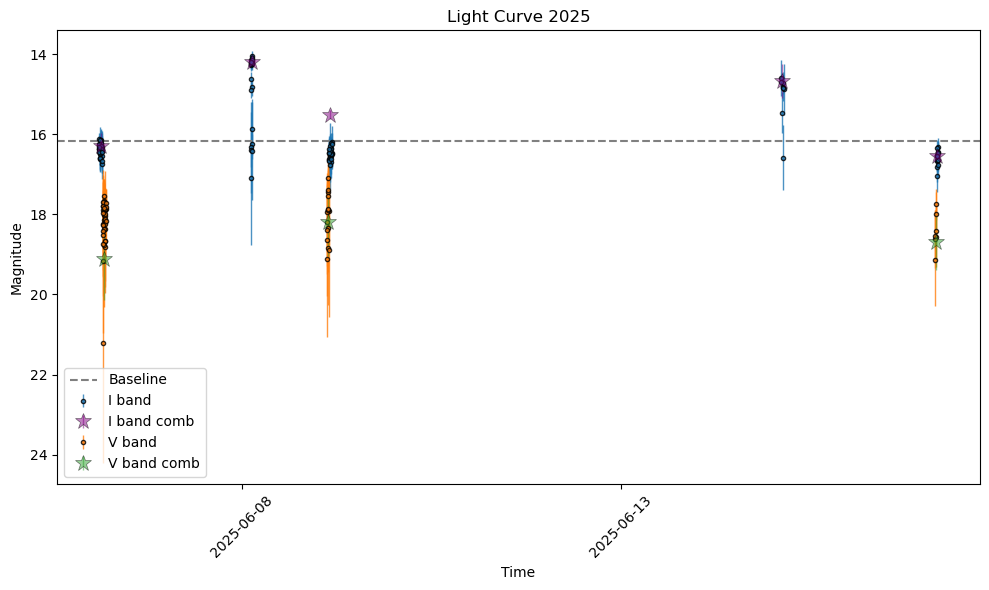

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Separate data into two groups based on year
lc_2024 = lc[lc['mjd_dt'].dt.year == 2024]
lc_2025 = lc[lc['mjd_dt'].dt.year == 2025]


for lc_data, year, ogle_mag in [(lc_2024, 2024, first_mag_ogle_i), (lc_2025, 2025, last_mag_ogle_i)]:
    if len(lc_data) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')
    
    ax.errorbar(lc_data.loc[non_comb_mask_i, 'mjd_dt'], lc_data.loc[non_comb_mask_i, 'I_mag'], 
                yerr=lc_data.loc[non_comb_mask_i, 'I_err'], fmt='o', alpha=0.8, ms=3, markeredgecolor='black',
                elinewidth=1, label='I band')
    ax.errorbar(lc_data.loc[comb_mask_i, 'mjd_dt'], lc_data.loc[comb_mask_i, 'I_mag'], 
                yerr=lc_data.loc[comb_mask_i, 'I_err'], fmt='*', elinewidth=1, markeredgecolor='black',
                color="purple", ms=12, alpha=0.5, markeredgewidth=0.5, label='I band comb')
    
    # Plot V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')
    
    ax.errorbar(lc_data.loc[non_comb_mask_v, 'mjd_dt'], lc_data.loc[non_comb_mask_v, 'V_mag'], 
                yerr=lc_data.loc[non_comb_mask_v, 'V_err'], fmt='o', alpha=0.8, ms=3, 
                markeredgecolor='black', elinewidth=1, label='V band')
    ax.errorbar(lc_data.loc[comb_mask_v, 'mjd_dt'], lc_data.loc[comb_mask_v, 'V_mag'], 
                yerr=lc_data.loc[comb_mask_v, 'V_err'], 
                ms=12, alpha=0.5, fmt='*', elinewidth=1, markeredgecolor='black', markeredgewidth=0.5, label='V band comb')
    ax.axhline(ogle_mag, color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Light Curve {year}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    #for file in lc_data['fname']:
    #    print(file)


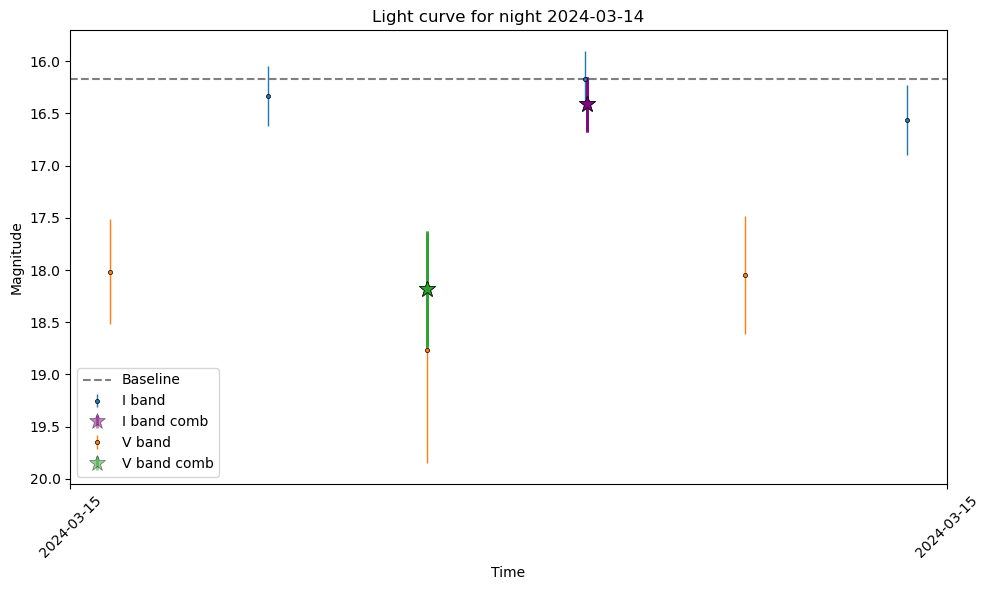

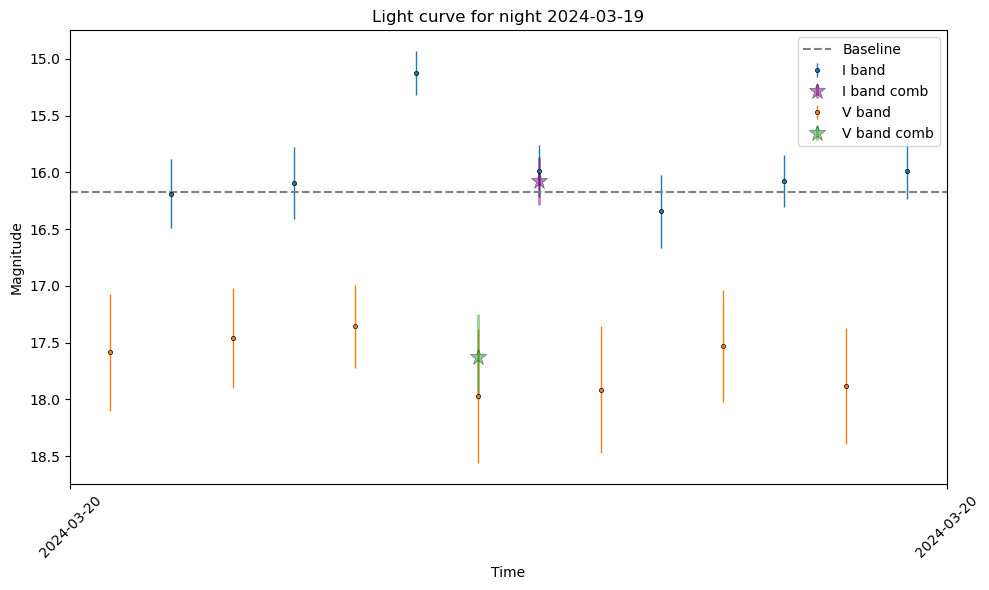

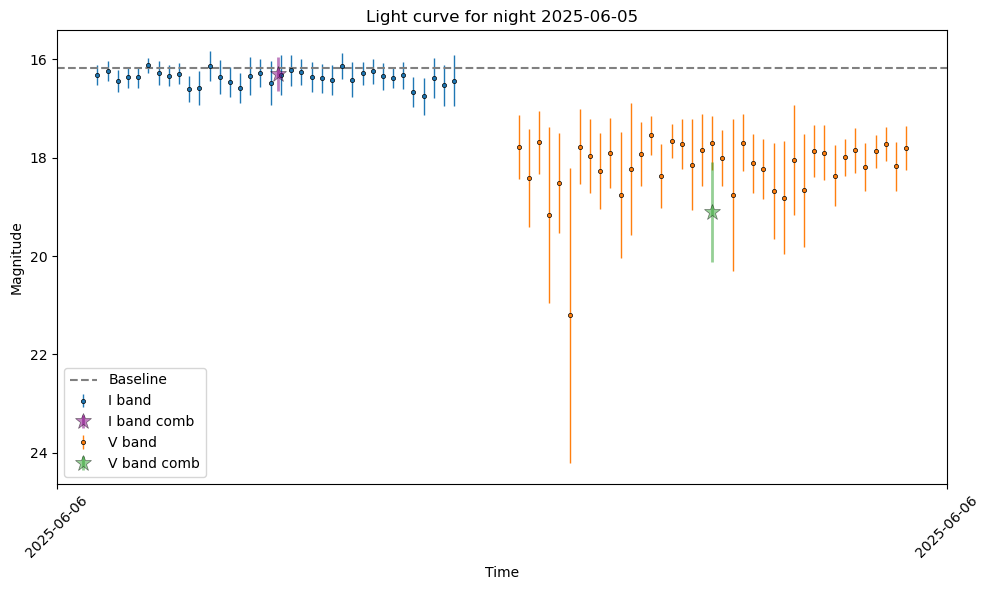

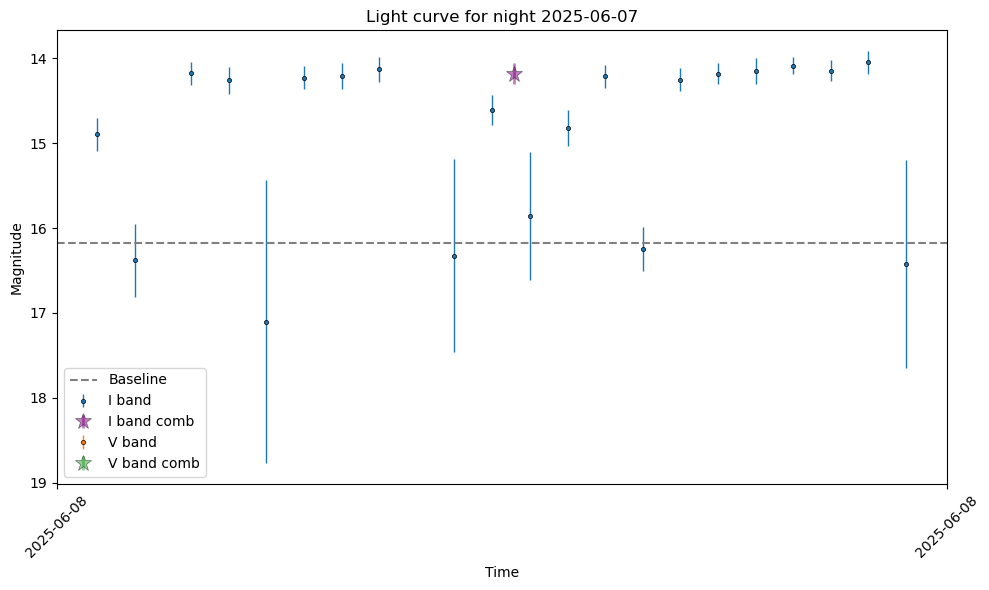

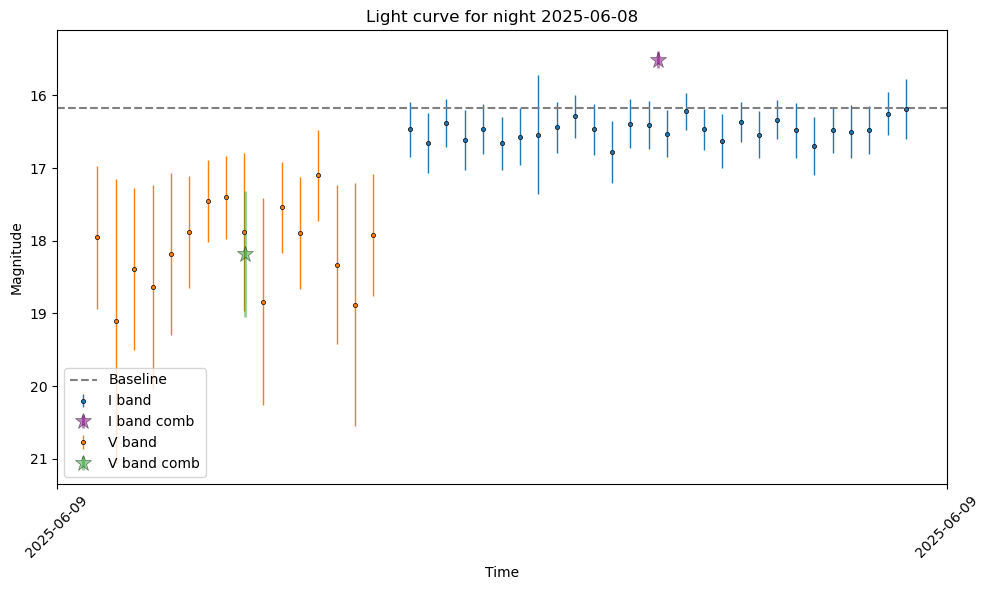

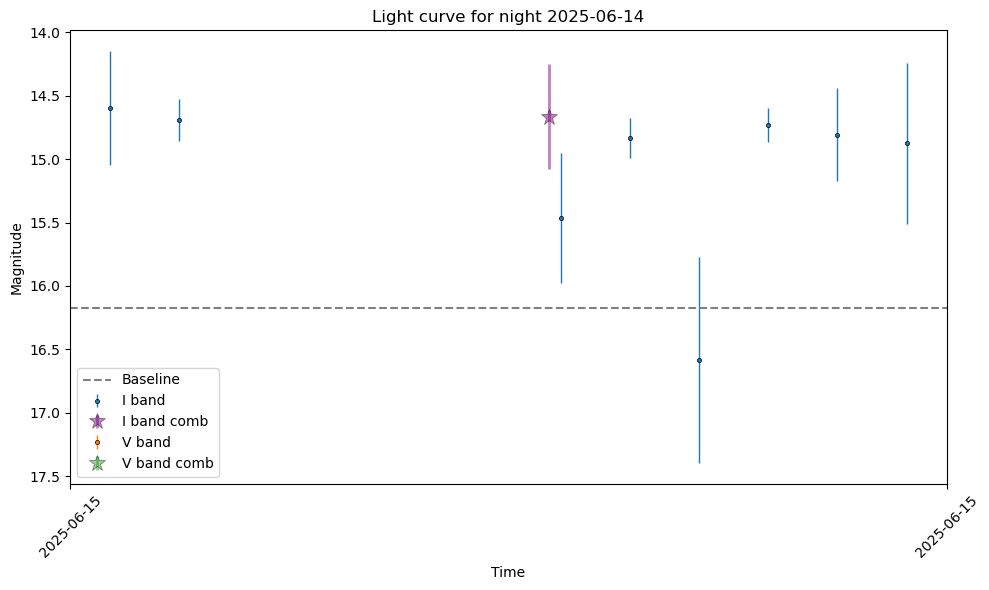

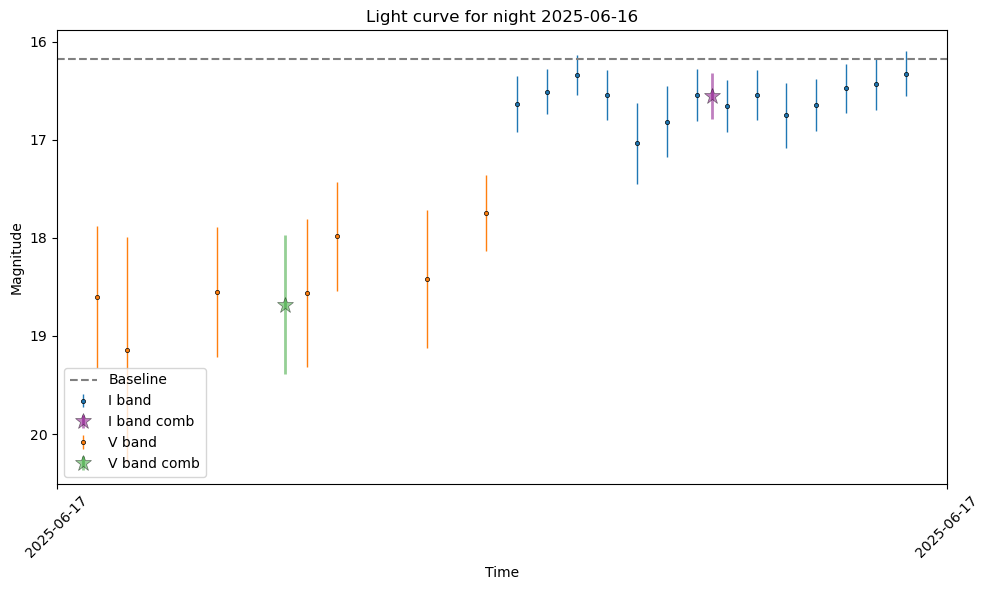

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ensure the “night” column exists (later cells define it, but if this cell is run early
# we recreate it here)
if 'night' not in lc.columns:
    lc['night'] = lc['mjd_dt'].apply(
        lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date()
    )
ogle_mag = {2024: first_mag_ogle_i, 2025: last_mag_ogle_i}
# loop over each night present in the lc table
for night_date, lc_data in lc.groupby('night'):
    fig, ax = plt.subplots(figsize=(10, 6))

    # I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_i, 'mjd_dt'],
                lc_data.loc[non_comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[non_comb_mask_i, 'I_err'],
                fmt='o',  ms=3, markeredgecolor='black', markeredgewidth=0.5,
                elinewidth=1, label='I band')
    ax.errorbar(lc_data.loc[comb_mask_i, 'mjd_dt'],
                lc_data.loc[comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[comb_mask_i, 'I_err'],
                fmt='*', alpha=0.5, elinewidth=2, markeredgecolor='black',
                color="purple", ms=12,  markeredgewidth=0.5,
                label='I band comb')

    # V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_v, 'mjd_dt'],
                lc_data.loc[non_comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[non_comb_mask_v, 'V_err'],
                fmt='o',  ms=3, markeredgewidth=0.5,
                markeredgecolor='black', elinewidth=1, label='V band')
    ax.errorbar(lc_data.loc[comb_mask_v, 'mjd_dt'],
                lc_data.loc[comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[comb_mask_v, 'V_err'],
                ms=12, alpha=0.5, fmt='*', elinewidth=2,
                markeredgecolor='black', markeredgewidth=0.5,
                label='V band comb')

    # photometry from the same night
    phot_night = phot[phot['Timestamp_dt'].dt.date == night_date]
    for f in phot_night['Filter'].unique():
        mask = (phot_night['Filter'] == f) & phot_night['Magnitude_clean'].notna()
        if f == "OGLE_I":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'],
                    's', ms=6, label=f)
        elif f == "G":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'] + 0.2,
                    's', ms=6, label="G+0.2")
    year = night_date.year
    ax.axhline(ogle_mag[year], color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Light curve for night {night_date}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    ax.legend(loc='best')
    plt.tight_layout()


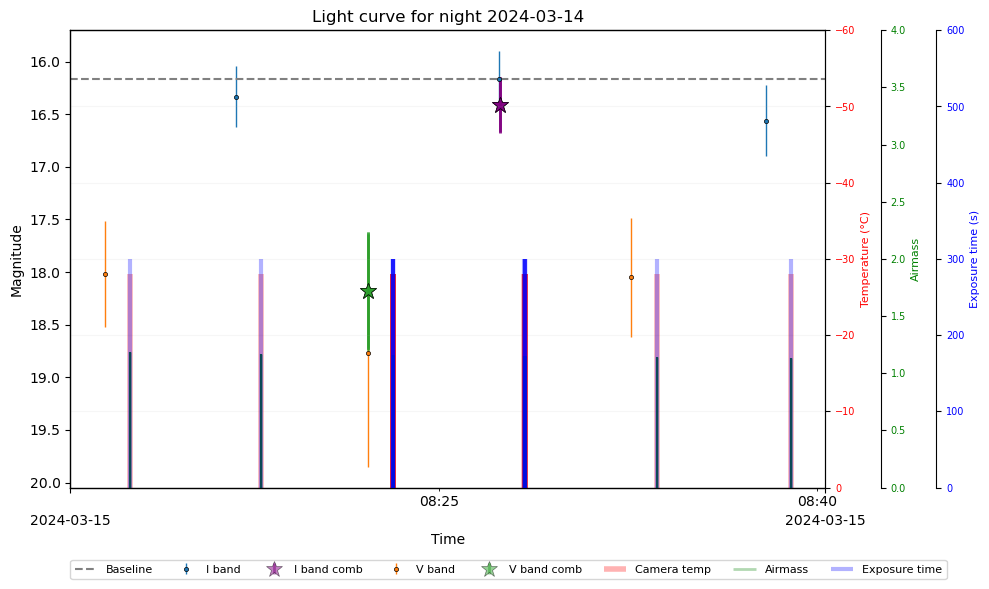

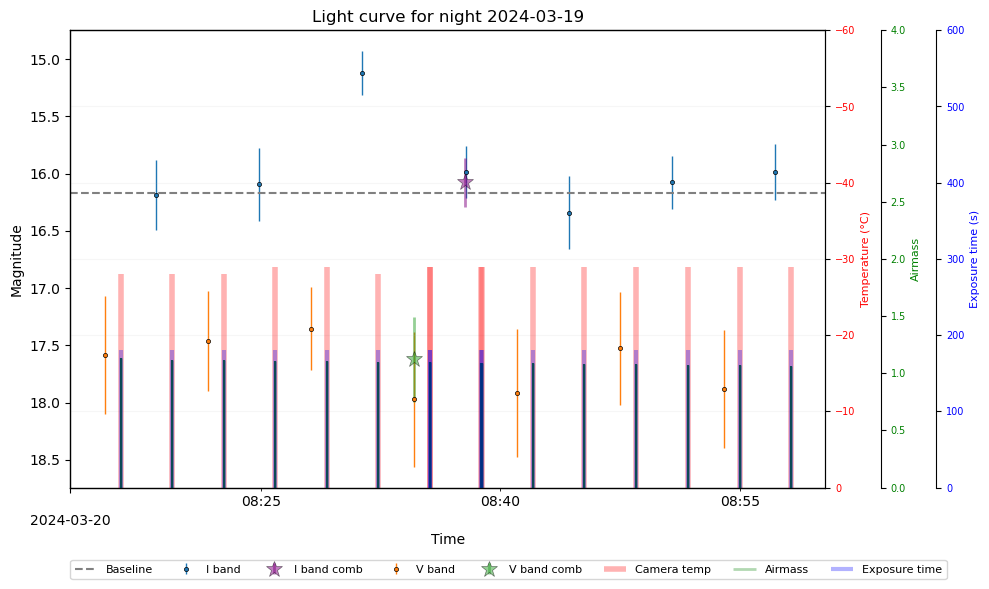

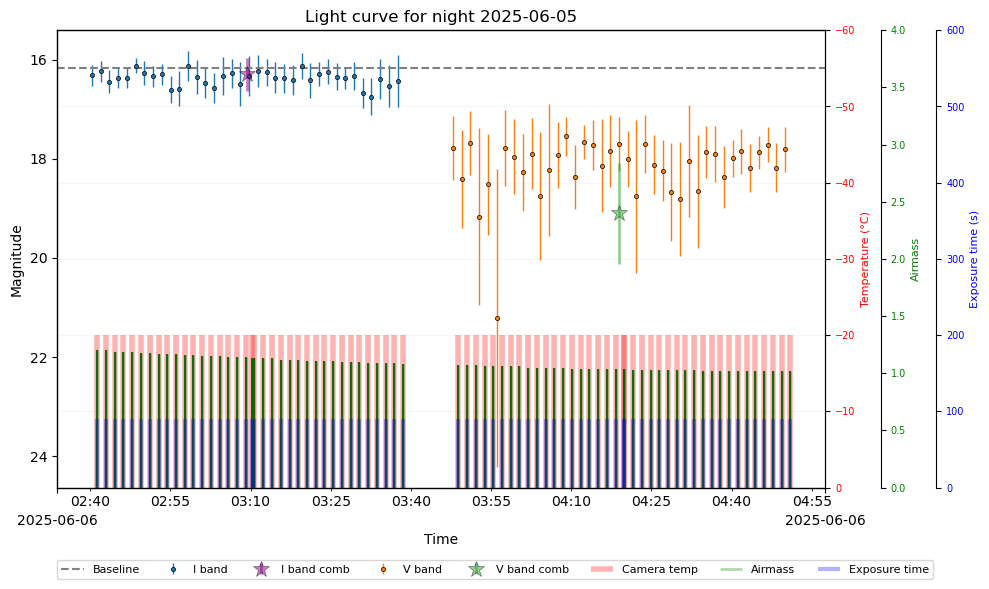

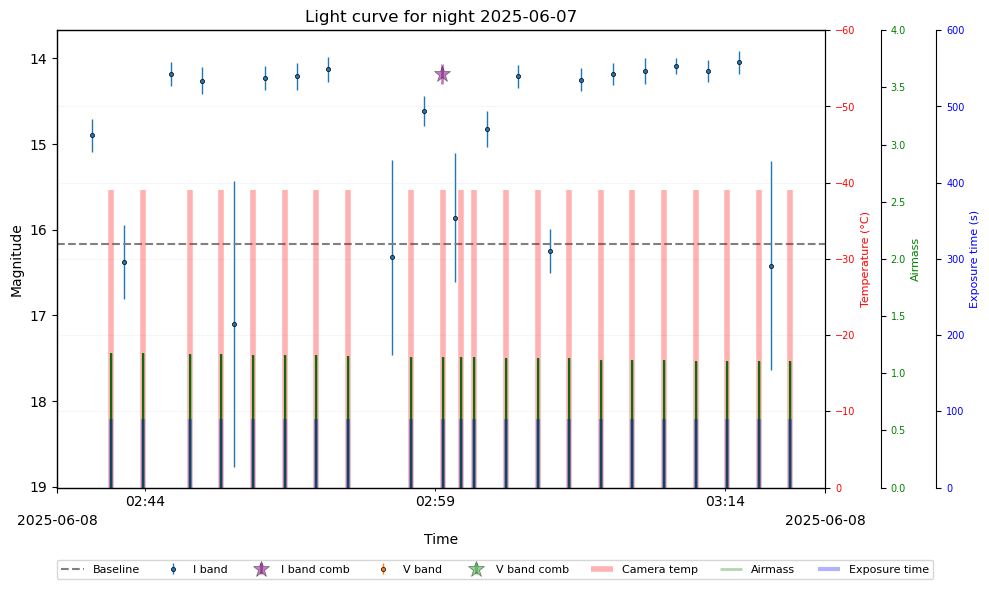

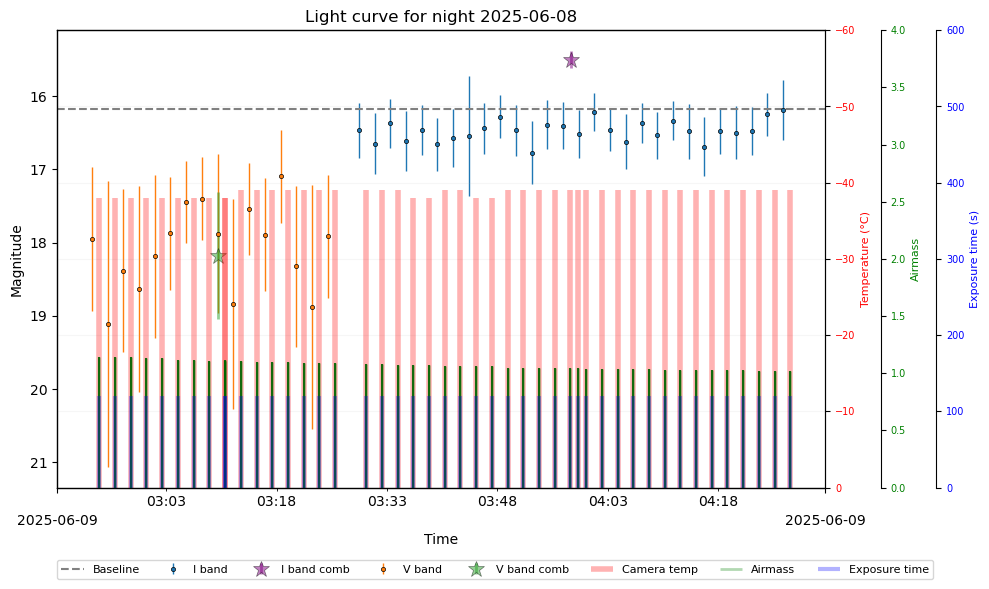

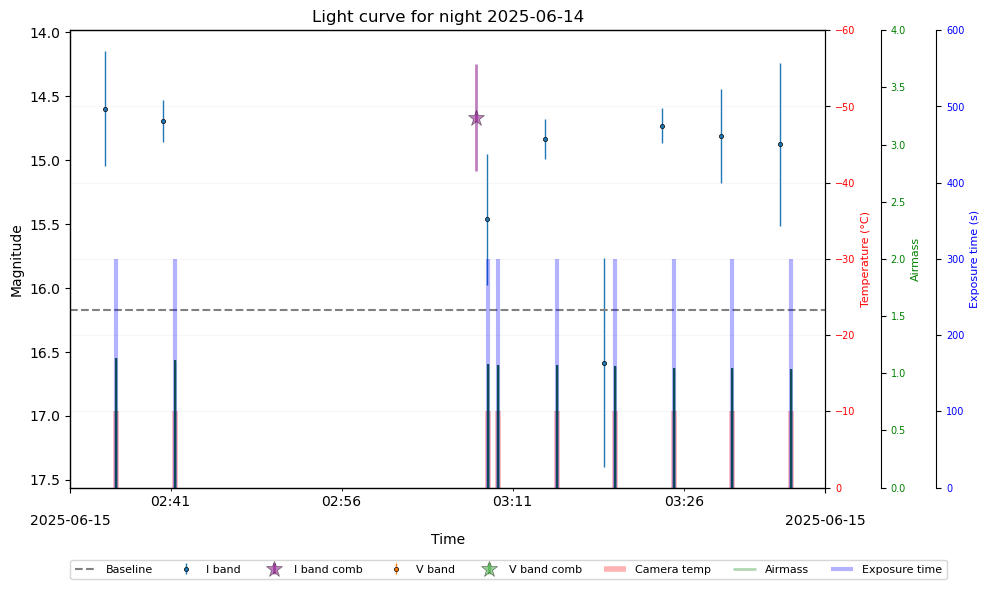

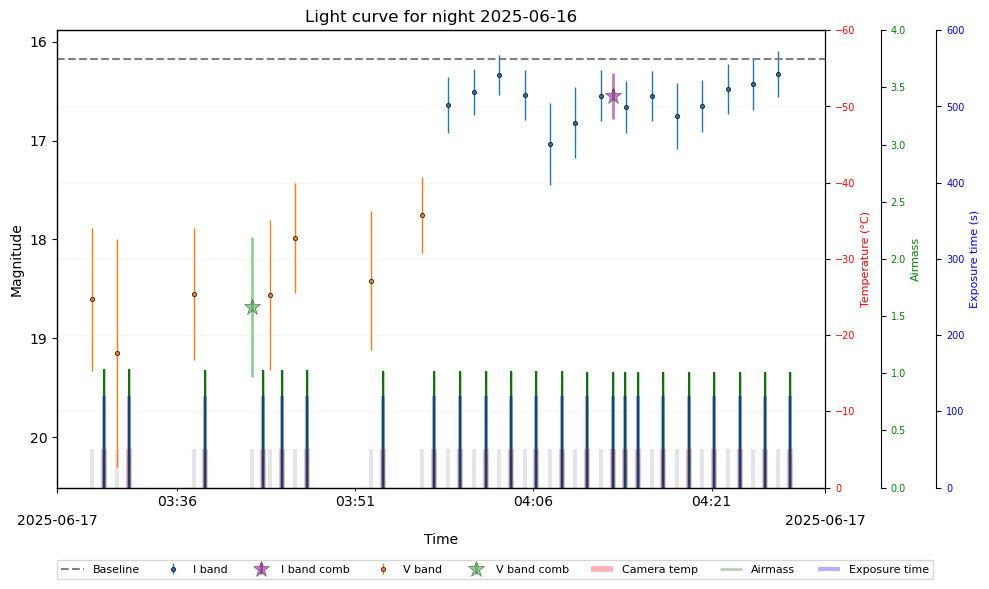

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


if 'night' not in lc.columns:
    lc['night'] = lc['mjd_dt'].apply(
        lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date()
    )

ogle_mag = {2024: first_mag_ogle_i, 2025: last_mag_ogle_i}


for night_date, lc_data in lc.groupby('night'):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax2 = ax.twinx()  # Create secondary y-axis
    ax3 = ax.twinx()  # Create tertiary y-axis
    ax4 = ax.twinx()  # Create quaternary y-axis

    # I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_i, 'mjd_dt'],
                lc_data.loc[non_comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[non_comb_mask_i, 'I_err'],
                fmt='o',  ms=3, markeredgecolor='black', markeredgewidth=0.5,
                elinewidth=1, label='I band')
    ax.errorbar(lc_data.loc[comb_mask_i, 'mjd_dt'],
                lc_data.loc[comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[comb_mask_i, 'I_err'],
                fmt='*', alpha=0.5, elinewidth=2, markeredgecolor='black',
                color="purple", ms=12, markeredgewidth=0.5,
                label='I band comb')

    # V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_v, 'mjd_dt'],
                lc_data.loc[non_comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[non_comb_mask_v, 'V_err'],
                fmt='o',  ms=3, markeredgewidth=0.5,
                markeredgecolor='black', elinewidth=1, label='V band')
    ax.errorbar(lc_data.loc[comb_mask_v, 'mjd_dt'],
                lc_data.loc[comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[comb_mask_v, 'V_err'],
                ms=12, alpha=0.5, fmt='*', elinewidth=2,
                markeredgecolor='black', markeredgewidth=0.5,
                label='V band comb')


    ax2.vlines(lc_data['mjd_dt']+pd.Timedelta(minutes=1), 0, lc_data["camtem"],  
               colors='red', alpha=0.3, linewidth=4, label='Camera temp')
    ax3.vlines(lc_data['mjd_dt']+pd.Timedelta(minutes=1), 0, lc_data["airmass"],
               colors='green', alpha=0.3, linewidth=2, label='Airmass')
    # darker thin line on top for contrast
    ax3.vlines(lc_data['mjd_dt']+pd.Timedelta(minutes=1), 0, lc_data["airmass"],
               colors='darkgreen', alpha=0.9, linewidth=1.5, zorder=10)
    ax4.vlines(lc_data['mjd_dt']+pd.Timedelta(minutes=1), 0, lc_data["exptime"], 
               colors='blue', alpha=0.3, linewidth=3, label='Exposure time')

    # photometry from the same night
    phot_night = phot[phot['Timestamp_dt'].dt.date == night_date]
    for f in phot_night['Filter'].unique():
        mask = (phot_night['Filter'] == f) & phot_night['Magnitude_clean'].notna()
        if f == "OGLE_I":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'],
                    's', ms=6, label=f)
        elif f == "G":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'] + 0.2,
                    's', ms=6, label="G+0.2")
    year = night_date.year
    ax.axhline(ogle_mag[year], color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Light curve for night {night_date}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax2.set_ylabel('Temperature (°C)', color='red', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=7)
    ax.invert_yaxis()
    ax2.invert_yaxis()
    # move the extra y‑axes outwards so the labels/ticks don’t sit on top of each other
    ax2.spines['right'].set_position(('outward', 0))
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.set_offset_position('right')

    ax3.spines['right'].set_position(('outward', 40))
    ax3.set_ylabel('Airmass', color='green', fontsize=8)
    ax3.yaxis.set_label_position('right')
    ax3.yaxis.set_offset_position('right')
    ax3.tick_params(axis='y', labelcolor='green', labelsize=7)

    ax4.spines['right'].set_position(('outward', 80))
    ax4.set_ylabel('Exposure time (s)', color='blue', fontsize=8)
    ax4.yaxis.set_label_position('right')
    ax4.yaxis.set_offset_position('right')
    ax4.tick_params(axis='y', labelcolor='blue', labelsize=7)
    ax2.set_ylim(0, -60)
    ax3.set_ylim(0, 4)
    ax4.set_ylim(0, 600)
    ax2.grid(alpha=0.1)
    # Combine legends from all axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    ax2.legend(lines1 + lines2 + lines3 + lines4, 
              labels1 + labels2 + labels3 + labels4, 
              loc=(0,-0.2), ncols=8, fontsize=8)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y-%m-%d'))
    # minor ticks every 15 min so you still see intra‑day spacing
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45)
    plt.tight_layout()
ax2.vlines(lc_data['mjd_dt'], 0, lc_data["camtem"], colors='gray', alpha=0.2, linewidth=3)

Index(['I', 'INSTRUME', 'I_err', 'I_inst', 'I_inst_err', 'SNR', 'TELESCOP',
       'V', 'V_err', 'V_inst', 'V_inst_err', 'aperature_correction',
       'aperature_correction_err', 'beta', 'fname', 'fwhm', 'fwhm_err',
       'instrument', 'lmag_inject', 'lmag_prob', 'method', 'mjd',
       'pixel_offset', 'subtraction', 'target_fwhm', 'telescope', 'time',
       'time_taken', 'xpix', 'ypix', 'zp_I', 'zp_I_err', 'zp_V', 'zp_V_err',
       'I_mag', 'V_mag', 'mjd_dt', 'camtem', 'airmass', 'exptime', 'night'],
      dtype='object')
6 0.0028888000000000004


ValueError: could not convert string to float: 'v0001'

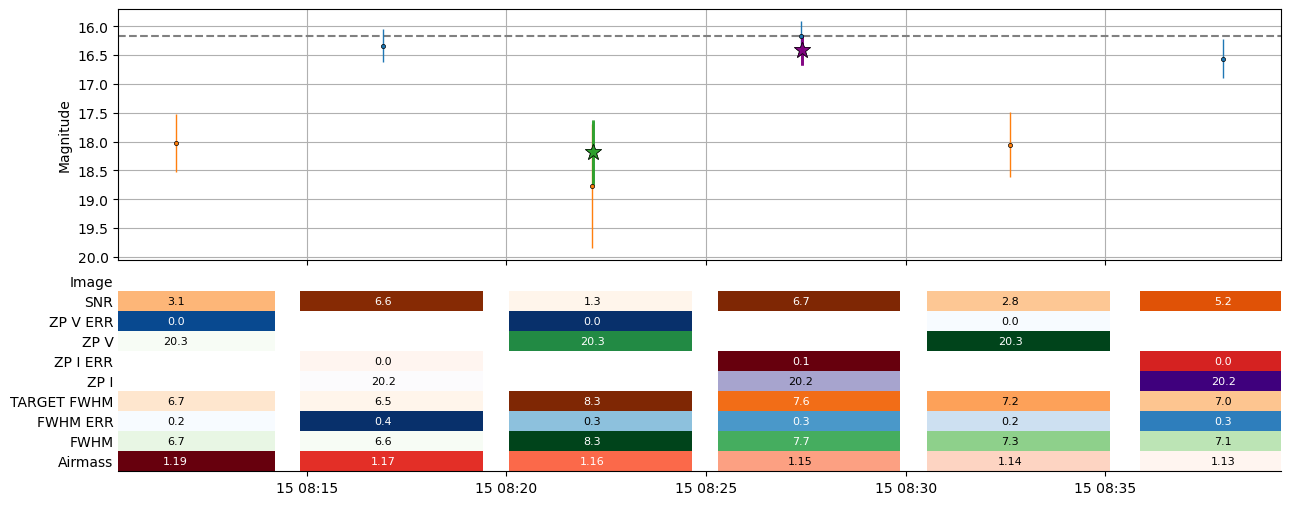

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

lc["image_id"] = lc["fname"].str.split("_").str[-3].str.split("-").str[-1].str[-5:]
print(lc_data.columns)
def get_text_color(rgba):
    r, g, b = rgba[:3]
    luminance = 0.299*r + 0.587*g + 0.114*b
    return "black" if luminance > 0.6 else "white"

if 'night' not in lc.columns:
    lc['night'] = lc['mjd_dt'].apply(
        lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date()
    )

ogle_mag = {2024: first_mag_ogle_i, 2025: last_mag_ogle_i}



for night_date, lc_data in lc.groupby('night'):

    fig = plt.figure(figsize=(15, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 0.8], hspace=0.05)

    ax = fig.add_subplot(gs[0])
    ax_metrics = fig.add_subplot(gs[1], sharex=ax)

    # =========================
    # ===== LIGHT CURVE ======
    # =========================

    lc_data = lc_data.sort_values('mjd_dt')

    # I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')

    ax.errorbar(
        lc_data.loc[non_comb_mask_i, 'mjd_dt'],
        lc_data.loc[non_comb_mask_i, 'I_mag'],
        yerr=lc_data.loc[non_comb_mask_i, 'I_err'],
        fmt='o', ms=3,
        markeredgecolor='black',
        markeredgewidth=0.5,
        elinewidth=1,
        label='I band',
        zorder=20
    )

    ax.errorbar(
        lc_data.loc[comb_mask_i, 'mjd_dt'],
        lc_data.loc[comb_mask_i, 'I_mag'],
        yerr=lc_data.loc[comb_mask_i, 'I_err'],
        fmt='*',
        alpha=0.5,
        elinewidth=2,
        markeredgecolor='black',
        color="purple",
        ms=12,
        markeredgewidth=0.5,
        label='I band comb',
        zorder=20
    )

    # V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')

    ax.errorbar(
        lc_data.loc[non_comb_mask_v, 'mjd_dt'],
        lc_data.loc[non_comb_mask_v, 'V_mag'],
        yerr=lc_data.loc[non_comb_mask_v, 'V_err'],
        fmt='o',
        ms=3,
        markeredgewidth=0.5,
        markeredgecolor='black',
        elinewidth=1,
        label='V band',
        zorder=20
    )

    ax.errorbar(
        lc_data.loc[comb_mask_v, 'mjd_dt'],
        lc_data.loc[comb_mask_v, 'V_mag'],
        yerr=lc_data.loc[comb_mask_v, 'V_err'],
        ms=12,
        alpha=0.5,
        fmt='*',
        elinewidth=2,
        markeredgecolor='black',
        markeredgewidth=0.5,
        label='V band comb',
        zorder=20
    )
    ax.grid()
    # Photometry external
    phot_night = phot[phot['Timestamp_dt'].dt.date == night_date]

    for f in phot_night['Filter'].unique():
        mask = (phot_night['Filter'] == f) & phot_night['Magnitude_clean'].notna()

        if f == "OGLE_I":
            ax.plot(
                phot_night.loc[mask, 'Timestamp_dt'],
                phot_night.loc[mask, 'Magnitude_clean'],
                's', ms=6, label=f
            )
        elif f == "G":
            ax.plot(
                phot_night.loc[mask, 'Timestamp_dt'],
                phot_night.loc[mask, 'Magnitude_clean'] + 0.2,
                's', ms=6, label="G+0.2"
            )

    year = night_date.year
    ax.axhline(ogle_mag[year], color='gray', linestyle='--', label='Baseline')

    
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()

    ax.set_xlim(
        lc_data['mjd_dt'].min() - pd.Timedelta(minutes=1),
        lc_data['mjd_dt'].max() + pd.Timedelta(minutes=1)
    )

    # Ocultar eje x superior
    ax.tick_params(axis='x', which='both', labelbottom=False)

    # =========================
    # ===== HEATMAP PANEL =====
    # =========================

    metrics = [
        ('airmass', 'Airmass'),
        ('fwhm', 'FWHM'),
        ('fwhm_err', 'FWHM ERR'),
        ('target_fwhm', 'TARGET FWHM'),
        ('zp_I', 'ZP I'),
        ('zp_I_err', 'ZP I ERR'),
        ('zp_V', 'ZP V'),
        ('zp_V_err', 'ZP V ERR'),
        ('SNR', 'SNR'),
        ('image_id', 'Image')
    ]
    
    lc_data_non_comb = lc_data[~lc_data['fname'].str.contains('comb')]
    times = lc_data_non_comb['mjd_dt']
    x_days = mdates.date2num(times)

    n_times = len(times)
    n_metrics = len(metrics)

    ax_metrics.set_ylim(0, n_metrics)
    ax_metrics.set_yticks(np.arange(n_metrics) + 0.5)
    ax_metrics.set_yticklabels([m[1] for m in metrics])
    ax_metrics.set_xlim(x_days.min() - 0.001, x_days.max() + 0.001)

    ax_metrics.spines['top'].set_visible(False)
    ax_metrics.spines['right'].set_visible(False)
    ax_metrics.spines['left'].set_visible(False)
    ax_metrics.tick_params(axis='y', length=0)

    

    if len(x_days) > 1:
        width = lc_data_non_comb['mjd_dt'].drop_duplicates().sort_values().diff().min().total_seconds() / (24 * 3600) * 0.8
    else:
        width = 1e-4
    print(n_times, width)
    
        
    if n_times > 50:
        annot_size = 6
        annot_rot = 90
    else:
        annot_size = 8
        annot_rot = 0


    cmaps = [
        cm.Reds,
        cm.Greens,
        cm.Blues,
        cm.Oranges,
        cm.Purples,
        cm.Reds,
        cm.Greens,
        cm.Blues,
        cm.Oranges,
        cm.Purples,
        cm.Reds,
        cm.Greens,
        cm.Blues,
        cm.Oranges,
        cm.Purples
    ]
    

    for i, (col, label) in enumerate(metrics):

        if col == 'image_id':
            vals = lc_data_non_comb[col].astype(str).values
        else:
            vals = lc_data_non_comb[col].apply(
            lambda v: float(v) if (pd.notna(v) and not isinstance(v, list))
            else (float(v[0]) if (isinstance(v, list) and len(v) > 0) else np.nan)
            ).values

        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)

        if vmax == vmin:
            norm = mcolors.Normalize(vmin=vmin - 1, vmax=vmax + 1)
        else:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

        for j in range(n_times):

            val = vals[j]

            if np.isnan(val):
                facecolor = 'white'
            else:
                facecolor = cmaps[i](norm(val))

            rect = Rectangle(
                (x_days[j] - width/2, i),
                width*1.1,
                1,
                facecolor=facecolor,
                #edgecolor='black',
                linewidth=0.3
            )

            ax_metrics.add_patch(rect)
                            
            dec=1
            if col in ['camtem', 'exptime']:
                dec=0  # Sin decimales
            elif col == 'airmass':
                dec=2  # Dos decimales para airmass
            
            #val = np.round(val, 1)

            if not np.isnan(val):
                ax_metrics.text(
                    x_days[j],
                    i + 0.5,
                    f"{val:.{dec}f}",
                    ha='center',
                    va='center',
                    fontsize=annot_size,
                    color=get_text_color(facecolor),
                    rotation=annot_rot
                )

    ax_metrics.invert_yaxis()
    ax_metrics.set_xlabel('Time')

    ax_metrics.xaxis_date()
    ax_metrics.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax_metrics.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y-%m-%d'))
    ax_metrics.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    ax_metrics.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
    
    ax.set_title(f'Light curve: Night {night_date} | Temp {lc_data_non_comb["camtem"].mean():.1f}°C | Exptime {lc_data_non_comb["exptime"].mean():.0f}s')

    plt.xticks(rotation=0, fontsize=6)
    plt.tight_layout()
    plt.show()

In [216]:
lc_data_non_comb.columns

Index(['I', 'INSTRUME', 'I_err', 'I_inst', 'I_inst_err', 'SNR', 'TELESCOP',
       'V', 'V_err', 'V_inst', 'V_inst_err', 'aperature_correction',
       'aperature_correction_err', 'beta', 'fname', 'fwhm', 'fwhm_err',
       'instrument', 'lmag_inject', 'lmag_prob', 'method', 'mjd',
       'pixel_offset', 'subtraction', 'target_fwhm', 'telescope', 'time',
       'time_taken', 'xpix', 'ypix', 'zp_I', 'zp_I_err', 'zp_V', 'zp_V_err',
       'I_mag', 'V_mag', 'mjd_dt', 'camtem', 'airmass', 'exptime', 'night'],
      dtype='object')

268    i0003
246    i0004
244    i0005
254    i0006
242    i0007
       ...  
237    v0028
247    v0029
230    v0030
218    v0031
236    v0032
Name: fname, Length: 62, dtype: object

In [175]:
lc_data.columns

Index(['I', 'INSTRUME', 'I_err', 'I_inst', 'I_inst_err', 'SNR', 'TELESCOP',
       'V', 'V_err', 'V_inst', 'V_inst_err', 'aperature_correction',
       'aperature_correction_err', 'beta', 'fname', 'fwhm', 'fwhm_err',
       'instrument', 'lmag_inject', 'lmag_prob', 'method', 'mjd',
       'pixel_offset', 'subtraction', 'target_fwhm', 'telescope', 'time',
       'time_taken', 'xpix', 'ypix', 'zp_I', 'zp_I_err', 'zp_V', 'zp_V_err',
       'I_mag', 'V_mag', 'mjd_dt', 'camtem', 'airmass', 'exptime', 'night'],
      dtype='object')

In [155]:
col, cmaps[i](norm(val)), val, cmaps[i](val)

('SNR',
 (np.float64(0.3219838523644752),
  np.float64(0.1391464821222607),
  np.float64(0.5544175317185698),
  np.float64(1.0)),
 np.float64(8.2),
 (np.float64(0.24705882352941178),
  np.float64(0.0),
  np.float64(0.49019607843137253),
  np.float64(1.0)))

/tmp/ipykernel_4077/3700819761.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


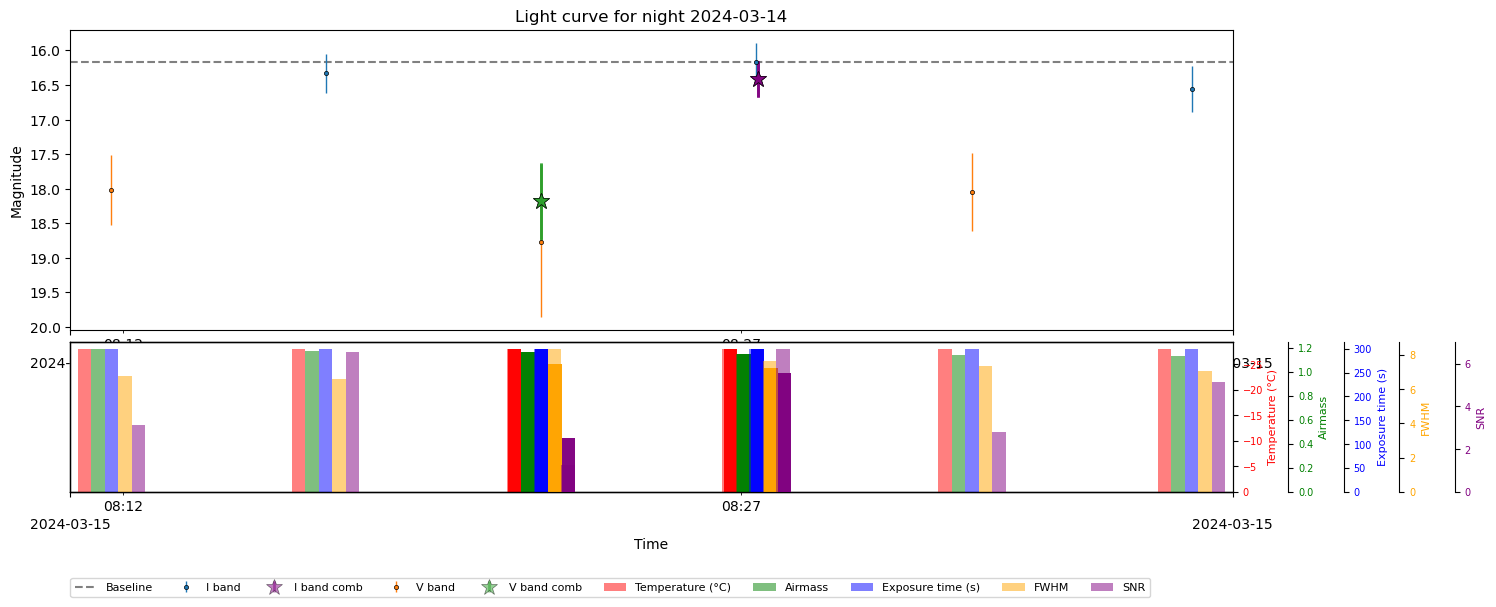

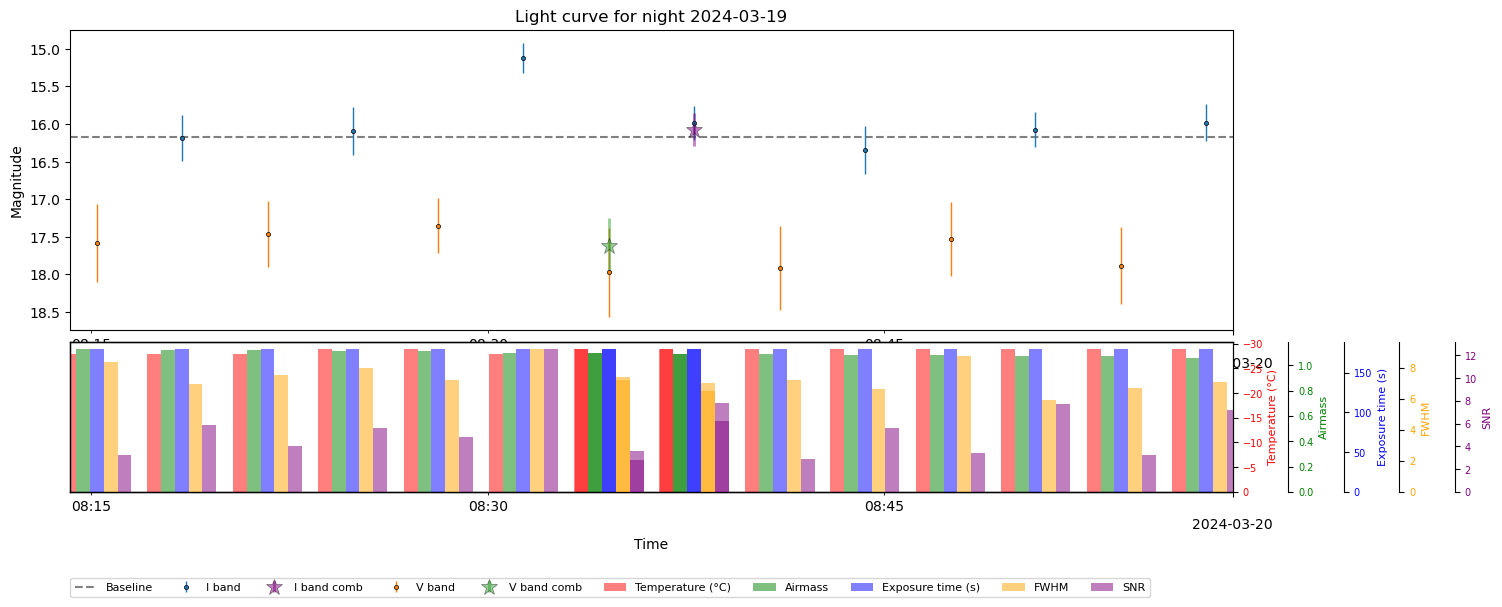

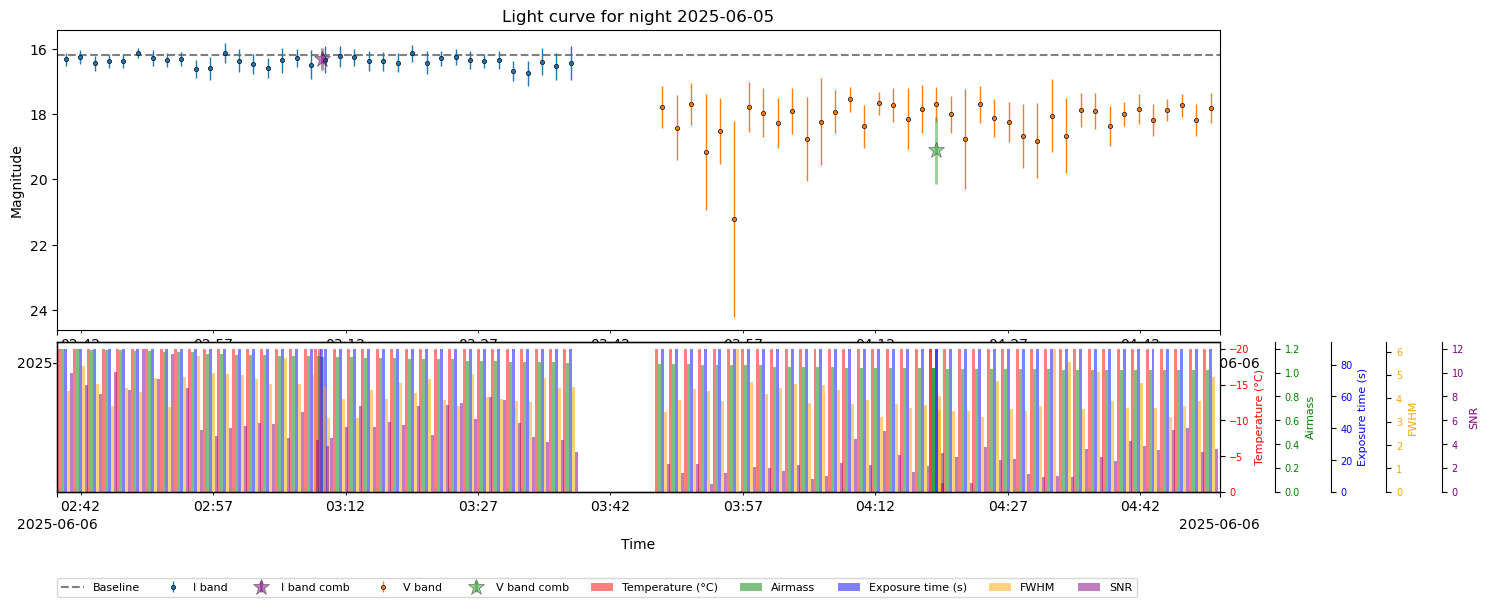

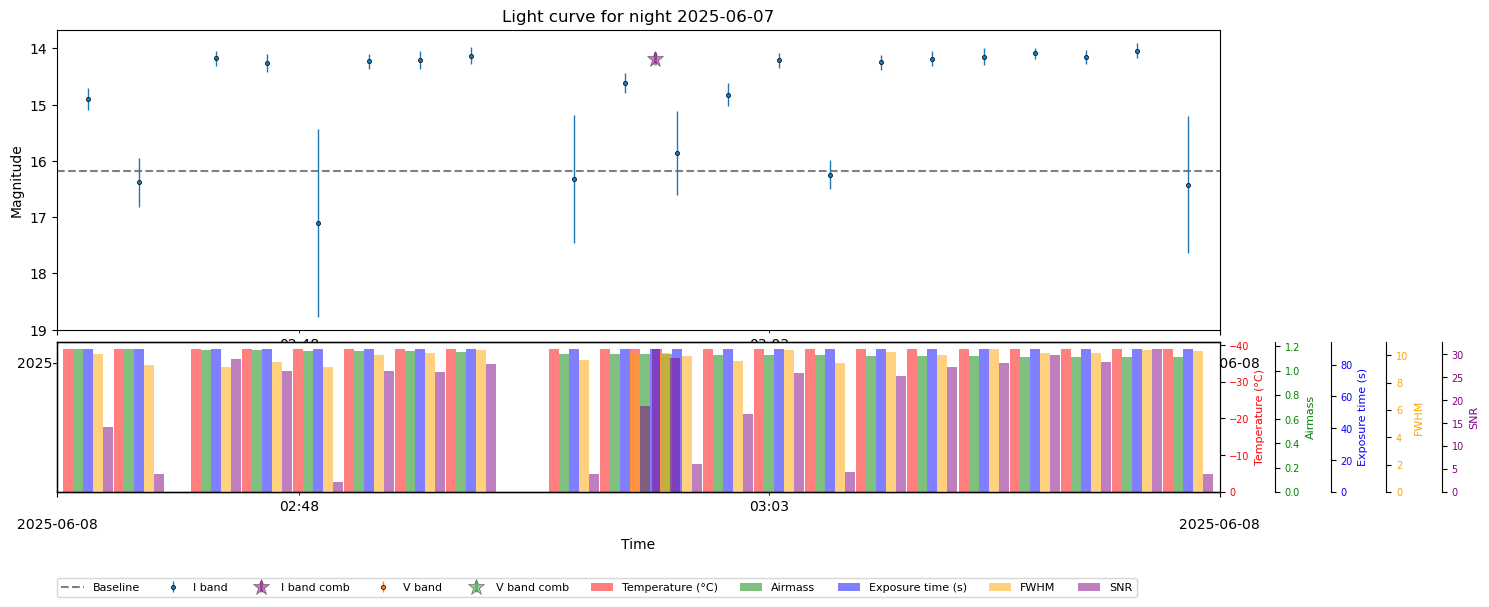

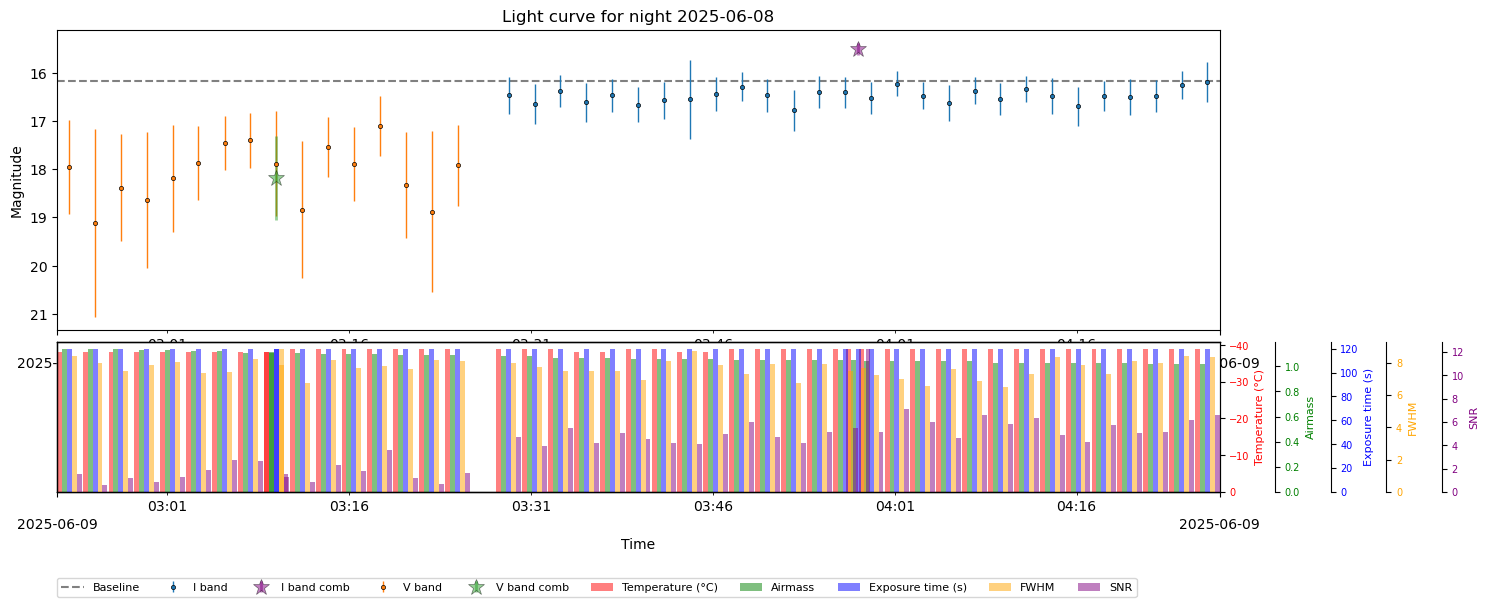

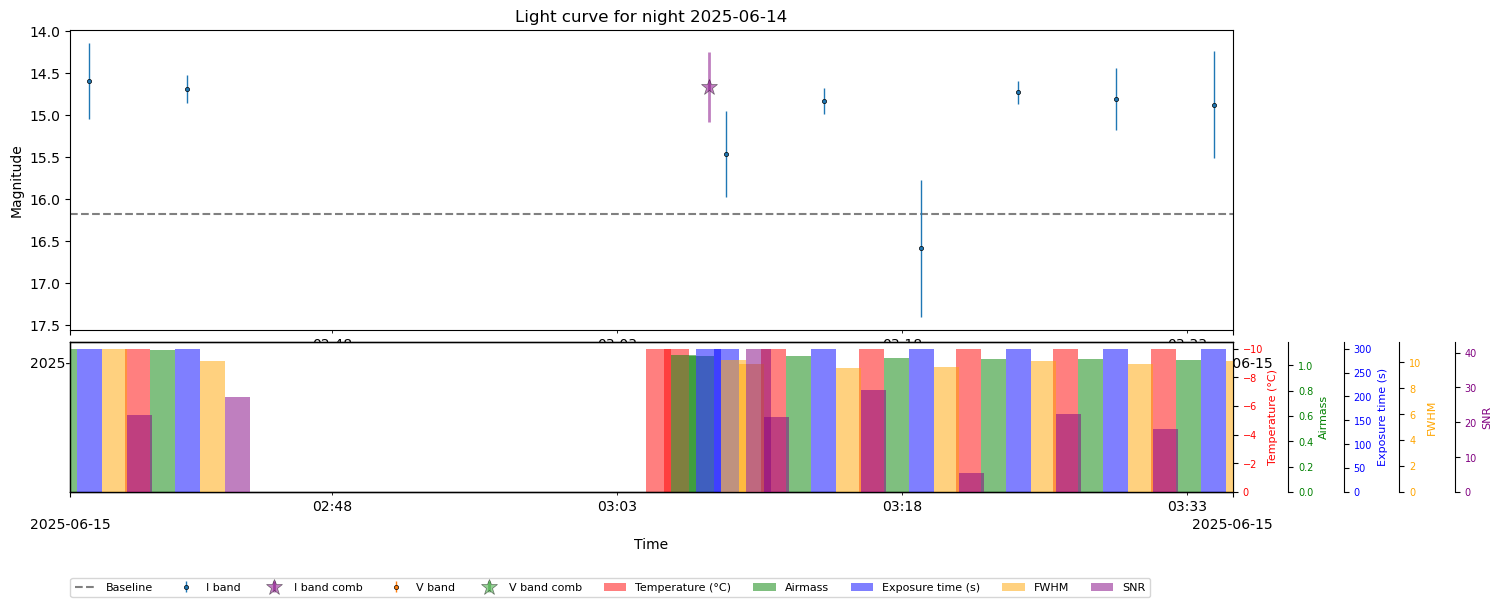

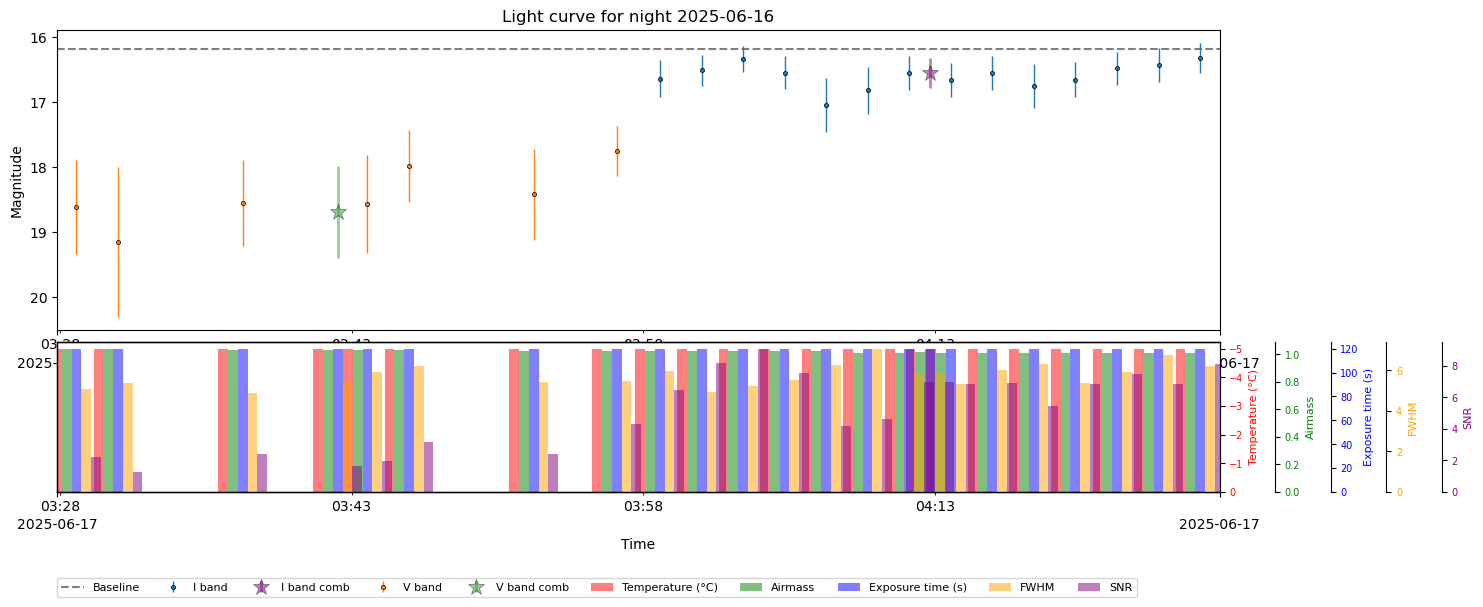

In [125]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


if 'night' not in lc.columns:
    lc['night'] = lc['mjd_dt'].apply(
        lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date()
    )

ogle_mag = {2024: first_mag_ogle_i, 2025: last_mag_ogle_i}
metrics = [
    ('camtem', 'Temperature (°C)', 'red'),
    ('airmass', 'Airmass', 'green'),
    ('exptime', 'Exposure time (s)', 'blue'),
    ('fwhm', 'FWHM', 'orange'),
    ('SNR', 'SNR', 'purple'),
]

for night_date, lc_data in lc.groupby('night'):
    fig = plt.figure(figsize=(15, 6))
    gs = fig.add_gridspec(1+len(metrics), 1, height_ratios=[1]+[0.2]*len(metrics), hspace=0.05)
    ax = fig.add_subplot(gs[0])
    ax_metrics = fig.add_subplot(gs[1], sharex=ax)
    
    # metrics to show as grouped bars (one axis per metric)

    # create one twin axis per metric
    extra_axes = [ax_metrics.twinx() for _ in metrics]

    # I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_i, 'mjd_dt'],
                lc_data.loc[non_comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[non_comb_mask_i, 'I_err'],
                fmt='o',  ms=3, markeredgecolor='black', markeredgewidth=0.5,
                elinewidth=1, label='I band', zorder=20)
    ax.errorbar(lc_data.loc[comb_mask_i, 'mjd_dt'],
                lc_data.loc[comb_mask_i, 'I_mag'],
                yerr=lc_data.loc[comb_mask_i, 'I_err'],
                fmt='*', alpha=0.5, elinewidth=2, markeredgecolor='black',
                color="purple", ms=12, markeredgewidth=0.5,
                label='I band comb', zorder=20)

    # V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')
    ax.errorbar(lc_data.loc[non_comb_mask_v, 'mjd_dt'],
                lc_data.loc[non_comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[non_comb_mask_v, 'V_err'],
                fmt='o',  ms=3, markeredgewidth=0.5,
                markeredgecolor='black', elinewidth=1, label='V band', zorder=20)
    ax.errorbar(lc_data.loc[comb_mask_v, 'mjd_dt'],
                lc_data.loc[comb_mask_v, 'V_mag'],
                yerr=lc_data.loc[comb_mask_v, 'V_err'],
                ms=12, alpha=0.5, fmt='*', elinewidth=2,
                markeredgecolor='black', markeredgewidth=0.5,
                label='V band comb', zorder=20)

    # photometry from the same night
    phot_night = phot[phot['Timestamp_dt'].dt.date == night_date]
    for f in phot_night['Filter'].unique():
        mask = (phot_night['Filter'] == f) & phot_night['Magnitude_clean'].notna()
        if f == "OGLE_I":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'],
                    's', ms=6, label=f)
        elif f == "G":
            ax.plot(phot_night.loc[mask, 'Timestamp_dt'],
                    phot_night.loc[mask, 'Magnitude_clean'] + 0.2,
                    's', ms=6, label="G+0.2")
    year = night_date.year
    ax.axhline(ogle_mag[year], color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Light curve for night {night_date}')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()

    ax.set_xlim(lc_data['mjd_dt'].min() - pd.Timedelta(minutes=1), lc_data['mjd_dt'].max() + pd.Timedelta(minutes=1))
    # apagar ticks del eje x de ax
    ax.set_xticks([])
    

    # compute bar widths based on median time spacing so bars don't overlap
    times_sorted = lc_data['mjd_dt'].sort_values()

    if len(times_sorted) > 1:
        duration = times_sorted.max() - times_sorted.min()

    n = len(metrics)
    candidate = (duration / len(lc_data))
    # sensible bounds: don't go below 10s, and don't exceed the duration
    min_width = pd.Timedelta(seconds=10)
    total_bar_width = max(min_width, candidate)

    total_bar_width_days = total_bar_width / pd.Timedelta(days=1)
   
    individual_width_days = total_bar_width_days / n
    # offsets to produce contiguous bars centered on the timestamp
    offsets_days = np.linspace(-total_bar_width_days/2 + individual_width_days/2,
                                total_bar_width_days/2 - individual_width_days/2, n)

    # convert times to matplotlib numeric days
    x_days = mdates.date2num(lc_data['mjd_dt'])

    # position and style each extra axis and plot bars
    outward_step = 40
    bar_containers = []

    
    for i, ((col, label, color), ax_extra) in enumerate(zip(metrics, extra_axes)):
        ax_extra.spines['right'].set_position(('outward', outward_step * i))
        ax_extra.set_ylabel(label, color=color, fontsize=8)
        ax_extra.yaxis.set_label_position('right')
        ax_extra.yaxis.set_offset_position('right')
        ax_extra.tick_params(axis='y', labelcolor=color, labelsize=7)
        ax_extra.tick_params(axis='x', labelsize=7)

        vals = lc_data[col].apply(lambda v: float(v) if (pd.notna(v) and not isinstance(v, list)) else
                                (float(v[0]) if (isinstance(v, list) and len(v) > 0) else np.nan))
        vals_filled = vals.fillna(0).values
        bars = ax_extra.bar(x_days + offsets_days[i], vals_filled,
                            width=individual_width_days, align='center',
                            color=color, alpha=0.5, label=label, zorder=5)
        bar_containers.append((bars, label))

        # keep sensible y-limits
        if col == 'camtem':
            ax_extra.invert_yaxis()
        #    ax_extra.set_ylim(0, -60)
        #elif col == 'airmass':
        #    ax_extra.set_ylim(0, 4)
        #elif col == 'exptime':
        #    ax_extra.set_ylim(0, 600)
        #elif col == 'fwhm':
        #    ax_extra.set_ylim(0, 30)
        #elif col == 'SNR':
        #    ax_extra.set_ylim(0, 100)

    # Hide left y-axis of ax_metrics
    ax_metrics.set_yticks([])
    ax_metrics.spines['left'].set_visible(False)

    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines_extra = []
    labels_extra = []
    for a in extra_axes:
        l, lab = a.get_legend_handles_labels()
        lines_extra += l
        labels_extra += lab
    extra_axes[0].legend(lines1 + lines_extra, labels1 + labels_extra,
                         loc=(0, -0.7), ncols=10, fontsize=8)

    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y-%m-%d'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
    
    ax_metrics.set_xlabel('Time')
    ax_metrics.xaxis_date()
    ax_metrics.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax_metrics.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y-%m-%d'))
    ax_metrics.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    ax_metrics.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45, fontsize=3)
    plt.tight_layout()

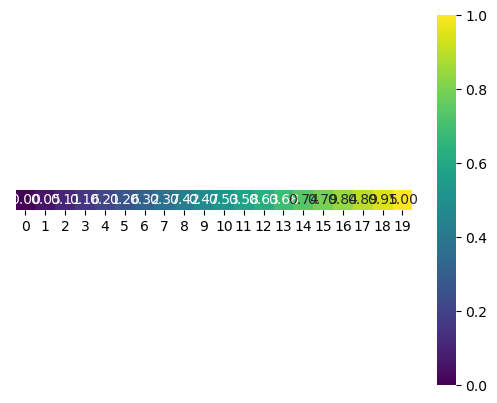

In [100]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

N = 20
data = np.linspace(0, 1, N).reshape(1, -1)

plt.figure()
sns.heatmap(
    data,
    ax=
    cmap="viridis",
    annot=True,        # ← activa anotaciones automáticas
    fmt=".2f",         # formato del número
    cbar=True,
    yticklabels=False,  # ocultar eje y si es una sola fila,
    square=True
)

plt.show()

In [13]:
candidate, duration, len(lc_data), total_bar_width, individual_width_days

(Timedelta('0 days 00:39:27.359999706'),
 Timedelta('0 days 00:59:11.039999559'),
 9,
 Timedelta('0 days 00:39:27.359999706'),
 0.005479999999319444)

In [15]:
duration/54

Timedelta('0 days 00:01:05.759999991')

Text(0, 0.5, 'Camera Temperature (°C)')

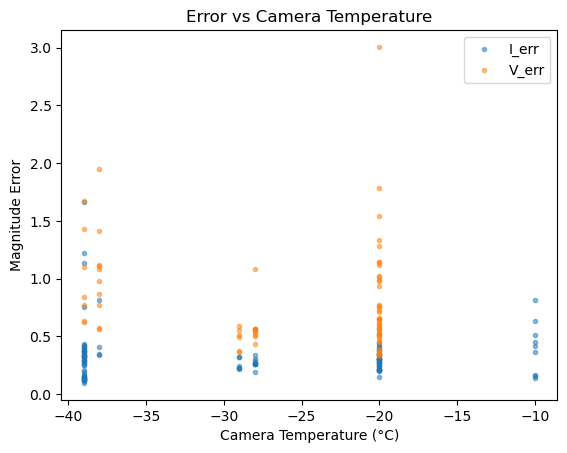

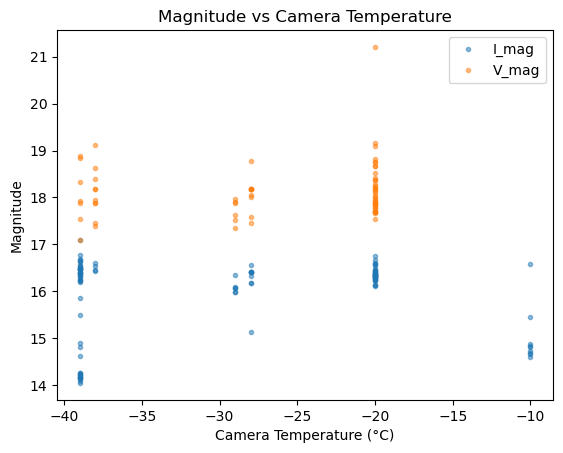

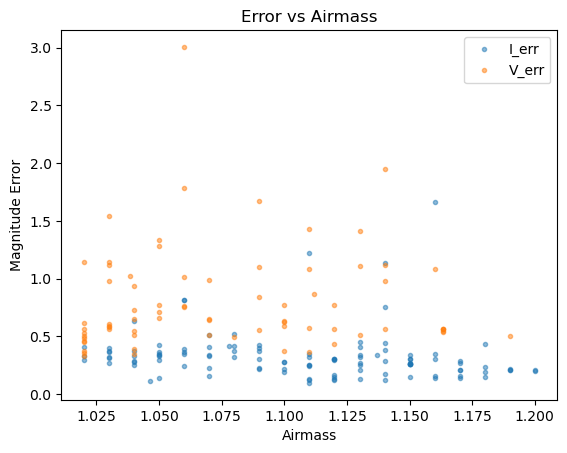

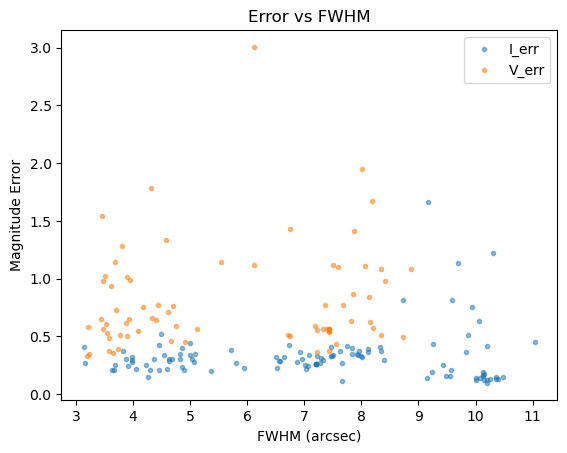

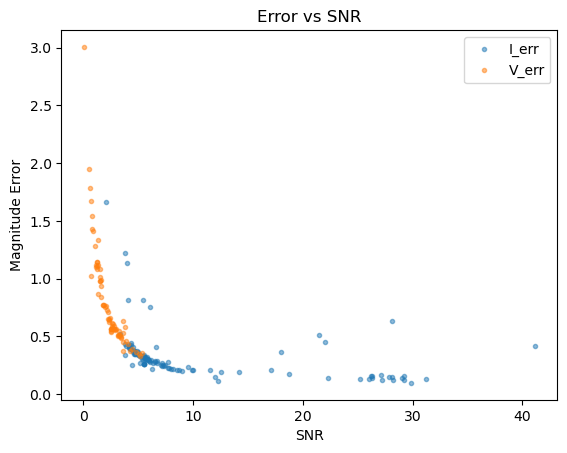

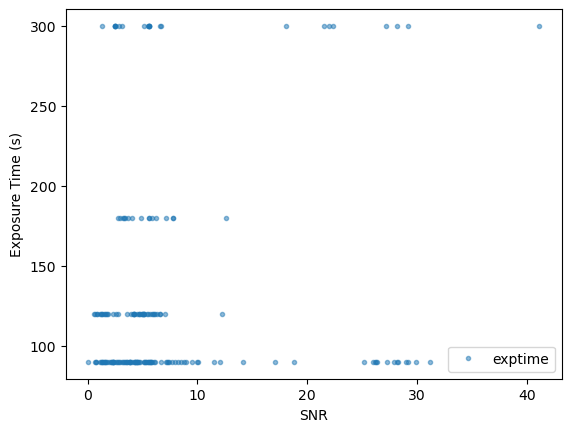

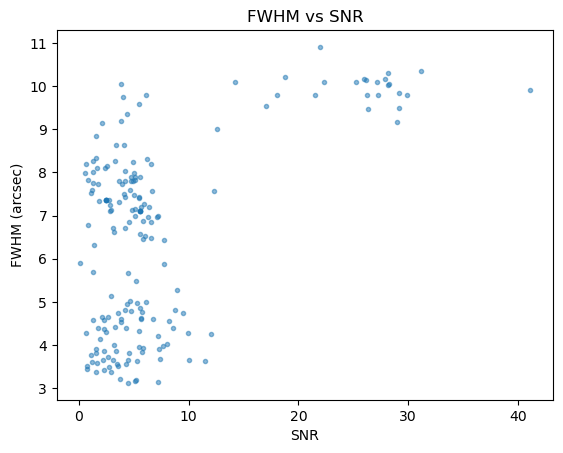

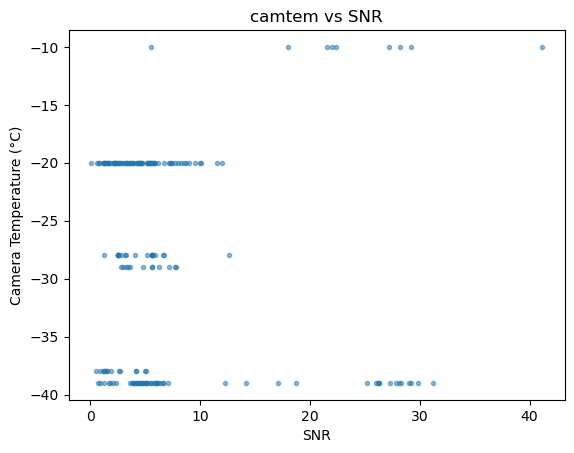

In [99]:
plt.title("Error vs Camera Temperature")
plt.plot(lc["camtem"], lc["I_err"], ".", alpha=0.5, label="I_err")
plt.plot(lc["camtem"], lc["V_err"], ".", alpha=0.5, label="V_err")
plt.legend()
plt.xlabel("Camera Temperature (°C)")
plt.ylabel("Magnitude Error")  
plt.figure()
plt.title("Magnitude vs Camera Temperature")
plt.plot(lc["camtem"], lc["I_mag"], ".", alpha=0.5, label ="I_mag")
plt.plot(lc["camtem"], lc["V_mag"], ".", alpha=0.5, label="V_mag")
plt.xlabel("Camera Temperature (°C)")
plt.ylabel("Magnitude")
plt.legend()
plt.figure()
plt.title("Error vs Airmass")
plt.plot(lc["airmass"], lc["I_err"], ".", alpha=0.5, label="I_err")
plt.plot(lc["airmass"], lc["V_err"], ".", alpha=0.5, label="V_err")
plt.xlabel("Airmass")
plt.ylabel("Magnitude Error")
plt.legend()
plt.figure()
plt.title("Error vs FWHM")
plt.plot(lc["fwhm"], lc["I_err"], ".", alpha=0.5, label="I_err")  
plt.plot(lc["fwhm"], lc["V_err"], ".", alpha=0.5, label="V_err")
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Magnitude Error")
plt.legend()
plt.figure()
plt.title("Error vs SNR")
plt.plot(lc["SNR"], lc["I_err"], ".", alpha=0.5, label="I_err")  
plt.plot(lc["SNR"], lc["V_err"], ".", alpha=0.5, label="V_err")
plt.xlabel("SNR")
plt.ylabel("Magnitude Error")
plt.legend()
plt.figure()
plt.plot(lc["SNR"], lc["exptime"], ".", alpha=0.5, label="exptime")  
plt.xlabel("SNR")
plt.ylabel("Exposure Time (s)")
plt.legend()
plt.figure()
plt.title("FWHM vs SNR")
plt.plot(lc["SNR"], lc["target_fwhm"], ".", alpha=0.5, label="FWHM")
plt.xlabel("SNR")
plt.ylabel("FWHM (arcsec)")
plt.figure()
plt.title("camtem vs SNR")
plt.plot(lc["SNR"], lc["camtem"], ".", alpha=0.5, label="Camera Temperature")
plt.xlabel("SNR")
plt.ylabel("Camera Temperature (°C)")


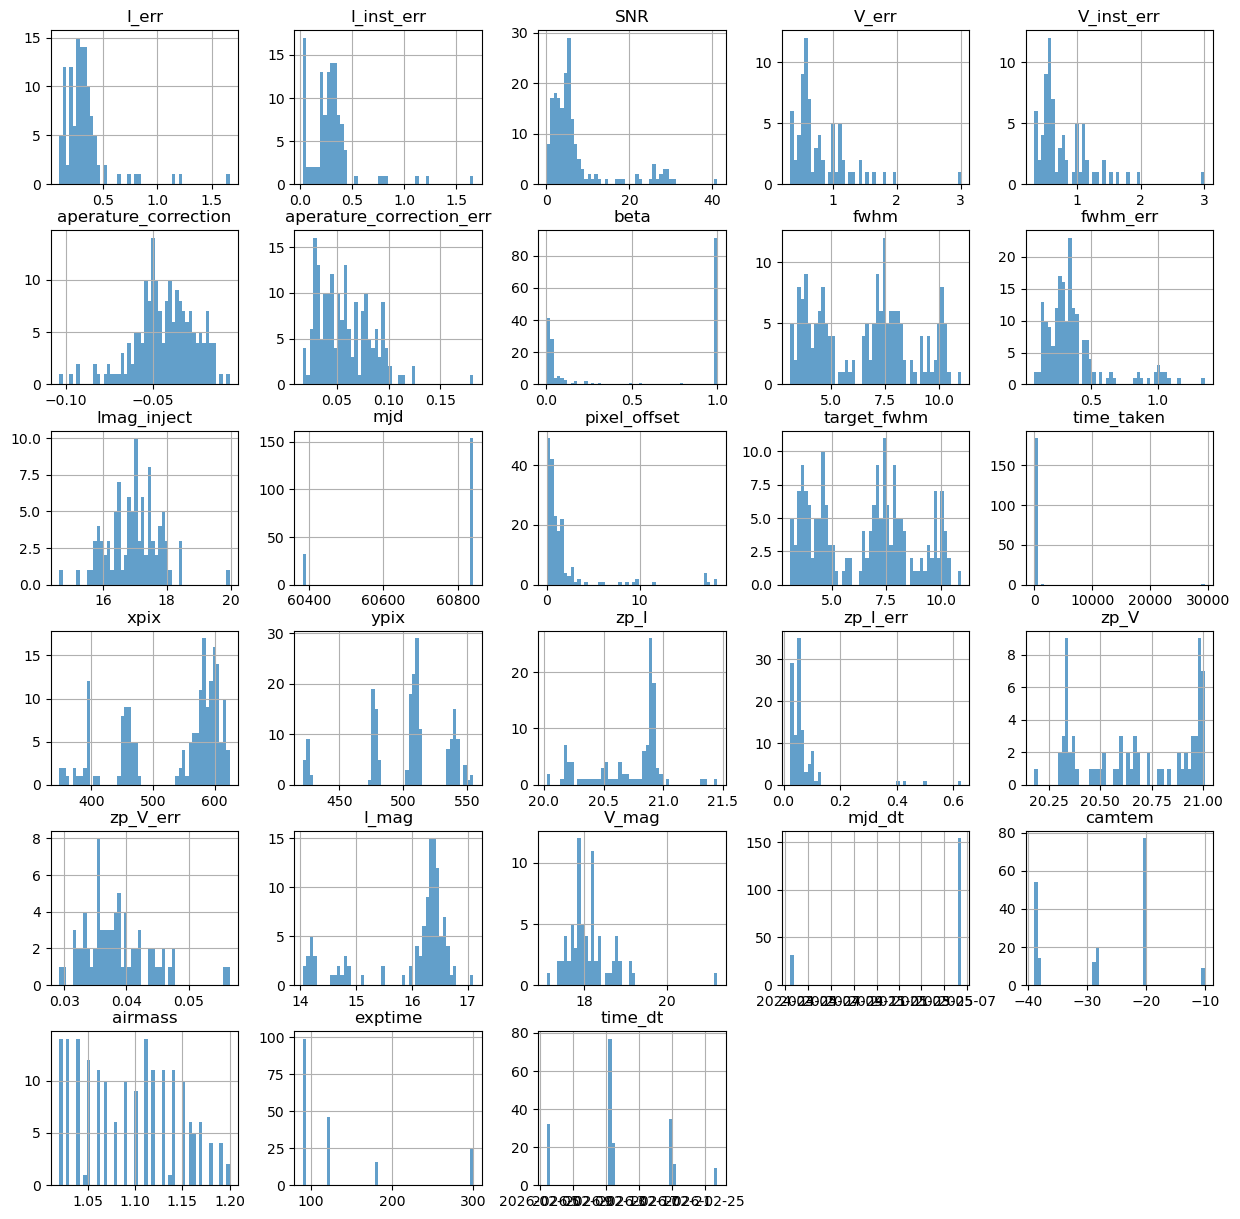

In [106]:
#plt.figure(figsize=(15, 15))
azes = lc.hist(figsize=(15, 15), bins=50, alpha=0.7)

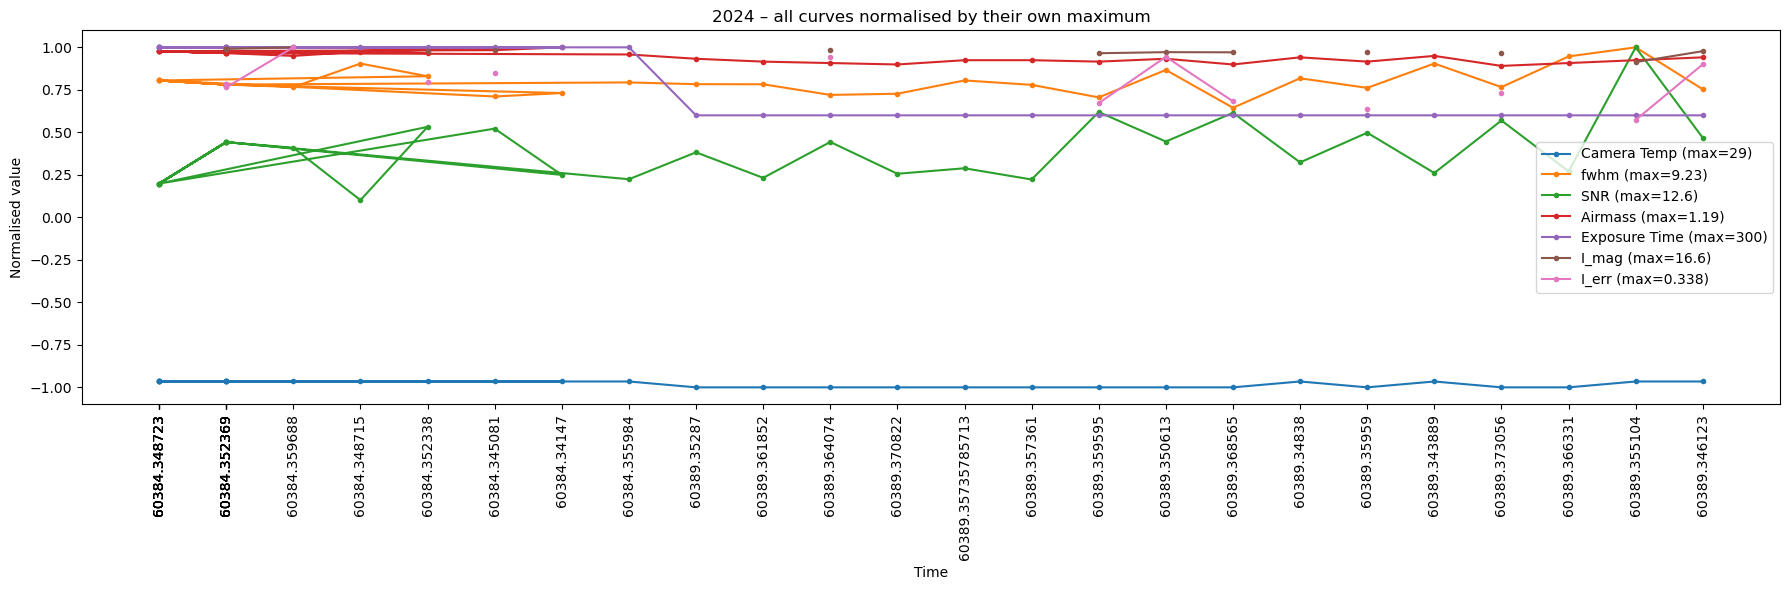

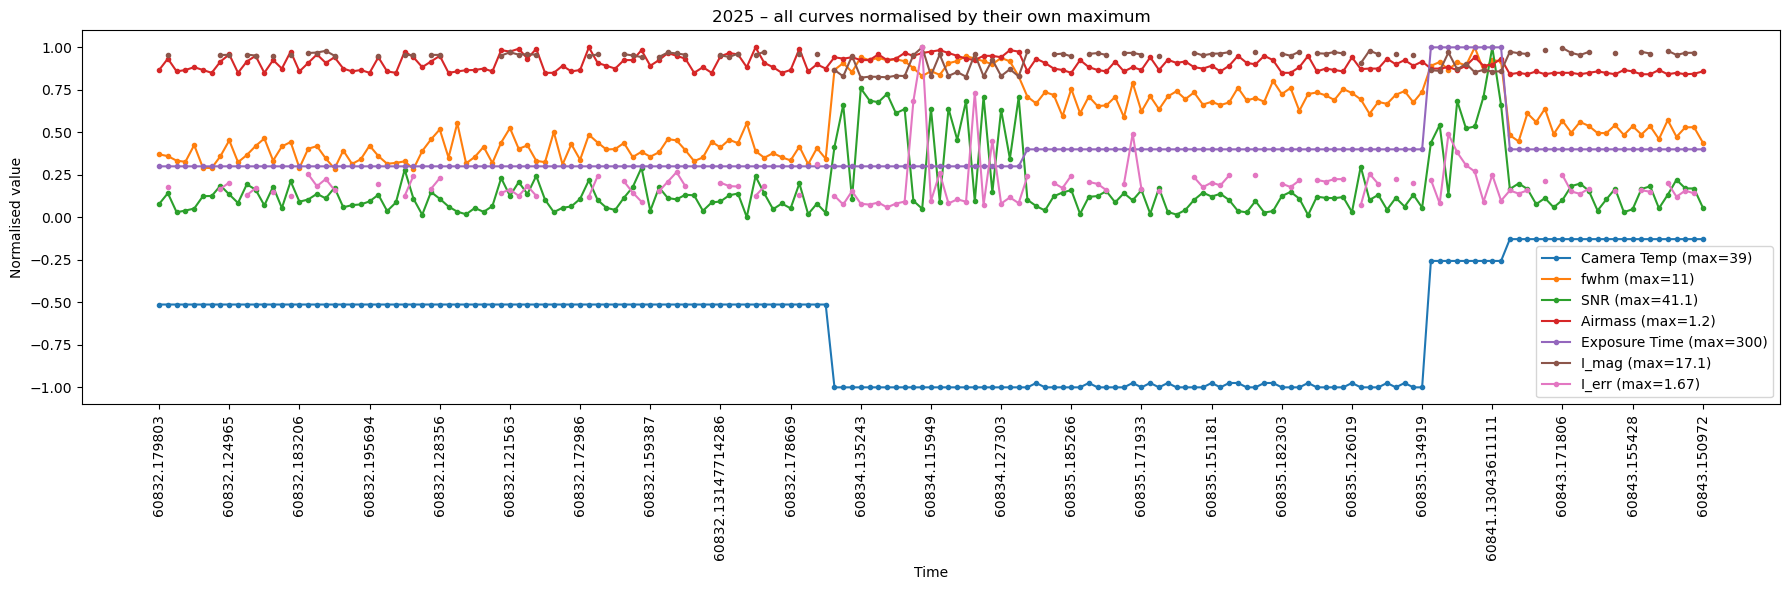

In [44]:
# helper that returns the (possibly negated) normalised series and a label
def norm_plot(ax, time, series, name, negate=False):
    m = series.max(skipna=True)
    if m == 0 or np.isnan(m):
        normed = series  # avoid division by zero
    else:
        normed = series / m
    if negate:
        normed = -normed
    lab = f"{name} (max={m:.3g})"
    ax.plot(time, normed, ".-", label=lab)

for year in (2024, 2025):
    lc_year = lc[lc['mjd_dt'].dt.year == year]
    if lc_year.empty:
        continue

    fig, ax = plt.subplots(figsize=(18, 6))
    t = lc_year["mjd"].astype(str)

    # camera temperature with the “–” kept
    norm_plot(ax, t, -lc_year["camtem"], "Camera Temp", negate=True)

    # the other quantities
    for col, name in [
        ("fwhm", "fwhm"),
        ("SNR", "SNR"),
        ("airmass", "Airmass"),
        ("exptime", "Exposure Time"),
        ("I_mag", "I_mag"),
        ("I_err", "I_err"),
    ]:
        norm_plot(ax, t, lc_year[col], name)

    ax.set_xlabel("Time")
    ax.set_ylabel("Normalised value")
    ax.set_title(f"{year} – all curves normalised by their own maximum")
    ax.set_xticks(t[::max(1, len(t)//20)])     # avoid overcrowding
    plt.xticks(rotation=90)
    ax.legend()
    plt.tight_layout()


In [109]:
lc["mjd_dt"]

0     2024-03-15 08:22:09.667200241
1     2024-03-15 08:27:24.681600017
2     2024-03-15 08:22:09.667200241
3     2024-03-15 08:27:24.681600017
4     2024-03-15 08:22:09.667200241
                   ...             
181   2025-06-15 03:08:44.016000120
182   2025-06-15 02:35:12.969600129
183   2025-06-15 03:13:52.032000043
184   2025-06-15 03:07:49.679999955
185   2025-06-15 02:40:22.022399775
Name: mjd_dt, Length: 186, dtype: datetime64[ns]

<Axes: >

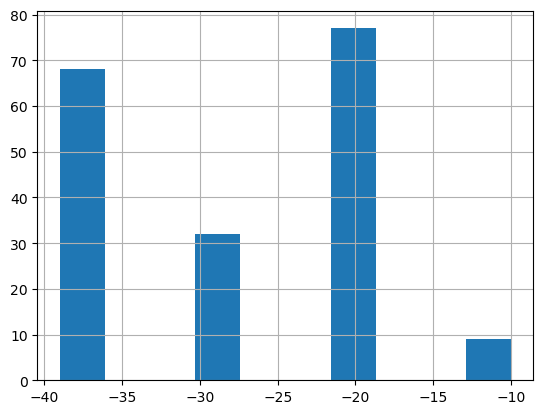

In [106]:
from astropy.io import fits


temperature = []


for file in lc.fname:
    try:
        # sólo se extrae la llave CAMTEM del primer HDU
        camtem = fits.getval(file, 'CAMTEM', ext=0)
        temperature.append(camtem)
    except Exception as e:
        print(f"Could not read CAMTEM for {file}: {e}")

        
lc['camtem'] = temperature
lc['camtem'] = pd.to_numeric(lc['camtem'], errors='coerce')
lc["camtem"].hist()

In [ ]:
plt.plot(I_df["Index"], I_df["I_mag"], "o-")

(34596, 186)

In [91]:
(lc_fnames[0].split("_APT.fits")[0]+".fit") #in df_obj["file"].values

'OGLE-2024-BLG-0034_v_comb.fit'

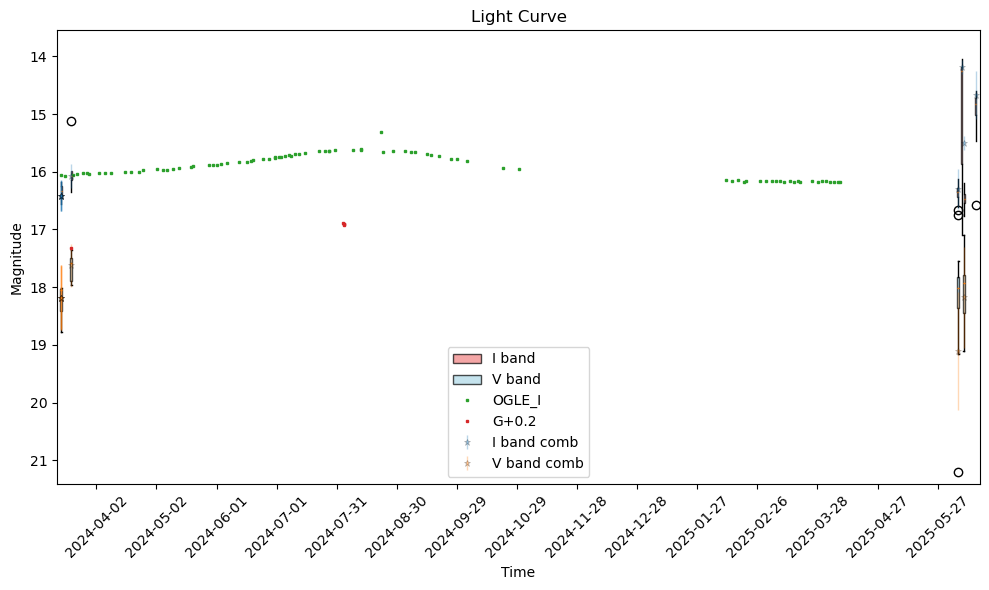

In [5]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Process lc data for I and V bands
lc['I_mag'] = lc['I'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['V_mag'] = lc['V'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['mjd_dt'] = pd.to_datetime(lc['mjd'], unit='D', origin=pd.Timestamp('1858-11-17'))

# Define night: from 7pm one day to 9am next day
lc['night'] = lc['mjd_dt'].apply(lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date())

fig, ax = plt.subplots(figsize=(10, 6))
# Plot I band
mask_i = lc['I_mag'].notna()
comb_mask_i = mask_i & lc['fname'].str.contains('comb')
non_comb_mask_i = mask_i & ~lc['fname'].str.contains('comb')
# For non-comb I band, use boxplots per night
grouped_i = lc.loc[non_comb_mask_i].groupby('night')
if grouped_i.ngroups > 0:
    data_i = [group['I_mag'].dropna().values for _, group in grouped_i]
    positions_i = [mdates.date2num(group['mjd_dt'].median()) for _, group in grouped_i]
    ax.boxplot(data_i, positions=positions_i, widths=0.5, patch_artist=True, 
               boxprops=dict(facecolor='lightcoral', alpha=0.7), label='I band')
ax.xaxis_date()
ax.errorbar(lc.loc[comb_mask_i, 'mjd_dt'], lc.loc[comb_mask_i, 'I_mag'], 
            yerr=lc.loc[comb_mask_i, 'I_err'], fmt='*', elinewidth=1, markeredgecolor='black',
            ms=5, alpha=0.3, markeredgewidth=0.5, label='I band comb')

# Plot V band
mask_v = lc['V_mag'].notna()
comb_mask_v = mask_v & lc['fname'].str.contains('comb')
non_comb_mask_v = mask_v & ~lc['fname'].str.contains('comb')
# For non-comb V band, use boxplots per night
grouped_v = lc.loc[non_comb_mask_v].groupby('night')
if grouped_v.ngroups > 0:
    data_v = [group['V_mag'].dropna().values for _, group in grouped_v]
    positions_v = [mdates.date2num(group['mjd_dt'].median()) for _, group in grouped_v]
    ax.boxplot(data_v, positions=positions_v, widths=1, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7), label='V band')
ax.xaxis_date()
ax.errorbar(lc.loc[comb_mask_v, 'mjd_dt'], lc.loc[comb_mask_v, 'V_mag'], 
            yerr=lc.loc[comb_mask_v, 'V_err'], fmt='*', elinewidth=1, markeredgecolor='black', 
            ms=5, alpha=0.3, markeredgewidth=0.5, label='V band comb')

ax.set_title('Light Curve')
ax.set_xlabel('Time')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()
plt.legend()


# Get unique filters in phot
filters = phot['Filter'].unique()
# Plot for each filter in phot
for f in filters:
    if f == "OGLE_I":
        mask = (phot['Filter'] == f) & phot['Magnitude_clean'].notna()
        ax.plot(phot.loc[mask, 'Timestamp_dt'], phot.loc[mask, 'Magnitude_clean'], 's',ms=2,  label=f)
    elif f == "G":
        mask = (phot['Filter'] == f) & phot['Magnitude_clean'].notna()
        ax.plot(phot.loc[mask, 'Timestamp_dt'], phot.loc[mask, 'Magnitude_clean']+0.2, 's',ms=2,  label="G+0.2")

ax.set_xlabel('Time')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()

ax.legend(loc='lower center')
ax.set_xlim(lc['mjd_dt'].min()-pd.Timedelta(days=2), lc['mjd_dt'].max()+pd.Timedelta(days=2))
ax.set_ylim(lc[['I_mag', 'V_mag']].max().max() + 0.2, lc[['I_mag', 'V_mag']].min().min() - 0.5)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=30))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()

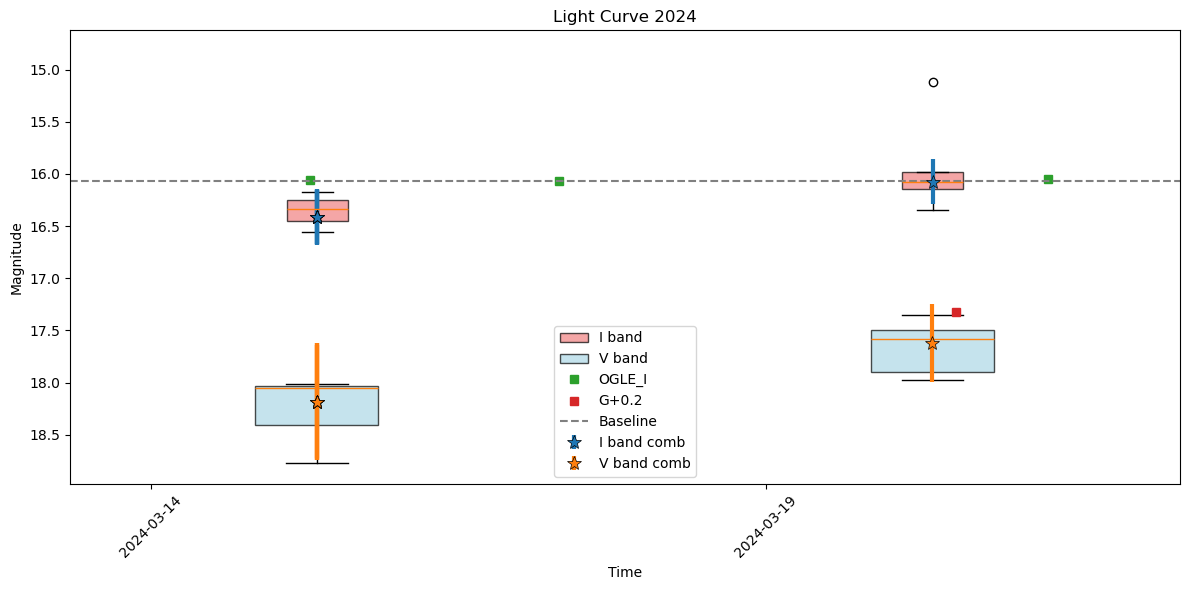

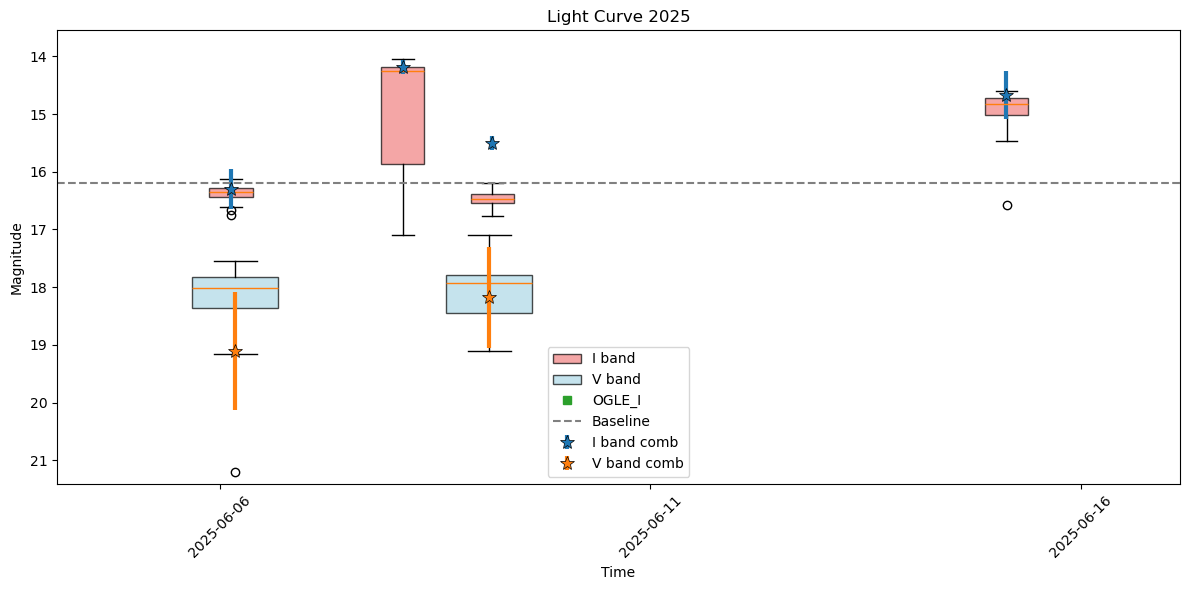

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Process lc data for I and V bands
lc['I_mag'] = lc['I'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['V_mag'] = lc['V'].apply(lambda x: float(x.strip('[]')) if pd.notna(x) and isinstance(x, str) else np.nan)
lc['mjd_dt'] = pd.to_datetime(lc['mjd'], unit='D', origin=pd.Timestamp('1858-11-17'))

# Define night: from 7pm one day to 9am next day
lc['night'] = lc['mjd_dt'].apply(lambda dt: dt.date() if dt.hour >= 19 else (dt - pd.Timedelta(days=1)).date())

# Separate data into two groups based on year
lc_2024 = lc[lc['mjd_dt'].dt.year == 2024]
lc_2025 = lc[lc['mjd_dt'].dt.year == 2025]

# Create two separate figures
for lc_data, year, fig_num, ogle_mag in [(lc_2024, 2024, 1, 16.07), (lc_2025, 2025, 2, 16.19)]:
    if len(lc_data) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot I band
    mask_i = lc_data['I_mag'].notna()
    comb_mask_i = mask_i & lc_data['fname'].str.contains('comb')
    non_comb_mask_i = mask_i & ~lc_data['fname'].str.contains('comb')
    
    # For non-comb I band, use boxplots per night
    grouped_i = lc_data.loc[non_comb_mask_i].groupby('night')
    if grouped_i.ngroups > 0:
        data_i = [group['I_mag'].dropna().values for _, group in grouped_i]
        positions_i = [mdates.date2num(group['mjd_dt'].median()) for _, group in grouped_i]
        ax.boxplot(data_i, positions=positions_i, widths=0.5, patch_artist=True, 
                   boxprops=dict(facecolor='lightcoral', alpha=0.7), label='I band')
    
    ax.errorbar(lc_data.loc[comb_mask_i, 'mjd_dt'], lc_data.loc[comb_mask_i, 'I_mag'], 
                yerr=lc_data.loc[comb_mask_i, 'I_err'], fmt='*', elinewidth=3, markeredgecolor='black',
                ms=10, alpha=1, markeredgewidth=0.5, label='I band comb')
    
    # Plot V band
    mask_v = lc_data['V_mag'].notna()
    comb_mask_v = mask_v & lc_data['fname'].str.contains('comb')
    non_comb_mask_v = mask_v & ~lc_data['fname'].str.contains('comb')
    
    grouped_v = lc_data.loc[non_comb_mask_v].groupby('night')
    if grouped_v.ngroups > 0:
        data_v = [group['V_mag'].dropna().values for _, group in grouped_v]
        positions_v = [mdates.date2num(group['mjd_dt'].median()) for _, group in grouped_v]
        ax.boxplot(data_v, positions=positions_v, widths=1, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7), label='V band')
    
    ax.errorbar(lc_data.loc[comb_mask_v, 'mjd_dt'], lc_data.loc[comb_mask_v, 'V_mag'], 
                yerr=lc_data.loc[comb_mask_v, 'V_err'], fmt='*', elinewidth=3, markeredgecolor='black', 
                ms=10, alpha=1, markeredgewidth=0.5, label='V band comb')
    
    # Plot phot data for this year
    phot_year = phot[phot['Timestamp_dt'].dt.year == year]
    filters_year = phot_year['Filter'].unique()
    for f in filters_year:
        if f == "OGLE_I":
            mask = (phot_year['Filter'] == f) & phot_year['Magnitude_clean'].notna()
            ax.plot(phot_year.loc[mask, 'Timestamp_dt'], phot_year.loc[mask, 'Magnitude_clean'], 's', ms=6, label=f)
        elif f == "G":
            mask = (phot_year['Filter'] == f) & phot_year['Magnitude_clean'].notna()
            ax.plot(phot_year.loc[mask, 'Timestamp_dt'], phot_year.loc[mask, 'Magnitude_clean']+0.2, 's', ms=6, label="G+0.2")
    ax.axhline(ogle_mag, color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Light Curve {year}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Magnitude')
    ax.set_xlim(lc_data['mjd_dt'].min() - pd.Timedelta(days=2), lc_data['mjd_dt'].max() + pd.Timedelta(days=2))
    ax.invert_yaxis()
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    ax.legend(loc='lower center')
    ax.set_ylim(lc_data[['I_mag', 'V_mag']].max().max() + 0.2, lc_data[['I_mag', 'V_mag']].min().min() - 0.5)
    plt.tight_layout()

In [80]:
from astropy.io import fits

hdul = fits.open("/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034v0002_wcs.fits")
header = dict(hdul[0].header)
hdul.close()
for key, value in header.items():
    print(f"{key}: {value}")

SIMPLE: True
BITPIX: -64
NAXIS: 2
NAXIS1: 1024
NAXIS2: 1024
CCDSIZE: [1:1024,1:1024]
CCDSUM: 1 1
PIXSIZE1: 24.0
PIXSIZE2: 24.0
ADCRATE: 
GAIN: 2.2
RDNOISE: 15
CAMTEM: -10.0
EXPTIME: 300.0
DATE: 2025-06-15T00:47:02
OBSERVAT: CASLEO
TELESCOP: HSH
DATE-OBS: 2025-06-15T03:41:53.981
TIME-OBS: 03:41:55.155
UT: 03:41:54.0
ST: 16:39:31.4
HA: -01:06:23.2
RA: 17:45:54.5
DEC: -39:07:13.1
EQUINOX: 2025.4
MJD-OBS: 60841.154097
ZD: 15.3
AIRMASS: 1.04
RA2000: 17:44:08.7
DEC2000: -39:06:39.8
DOME-AZ: 342.1
IMAGETYP: object
OBJECT: OGLE-2024-BLG-0034
INSTRUME: Direct CCD
INSTRMOD: 
OBSERVER: Makler
OPTELE: 
COMMENT: = ' '
PROG-ID: HSH-2025A-05
DETECTOR: STL-1001E
PIXSCALE: 0.53
FILTER01: (3) V
FILTER02: (6) Free
FILENAME: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/OGLE-2024-BLG-0034v0002.fit
FILTERS: V
OBJ_STAT: OK
CALIBZ: subtracted bias
BUNIT: adu
CALIBF: flat correction
ASTROMET: failure
